Dataset loaded successfully.
Raw dataset shape: (50401, 300)

Raw date range:
First date: 2014-12-31T23:00:00Z
Last date : 2020-09-30T23:00:00Z

Germany-related columns:
DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation

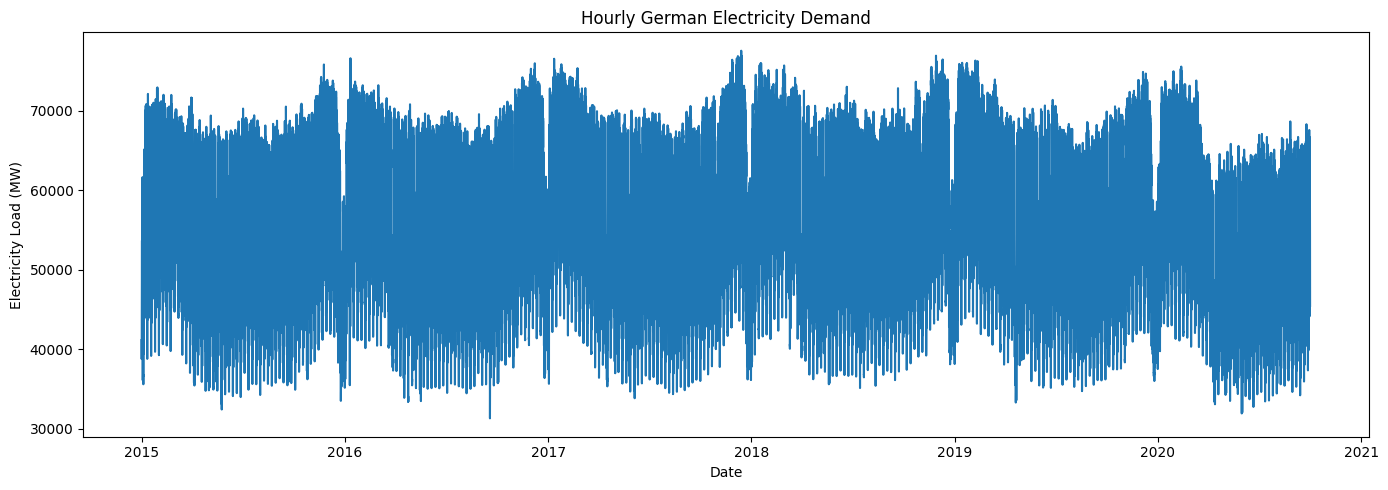

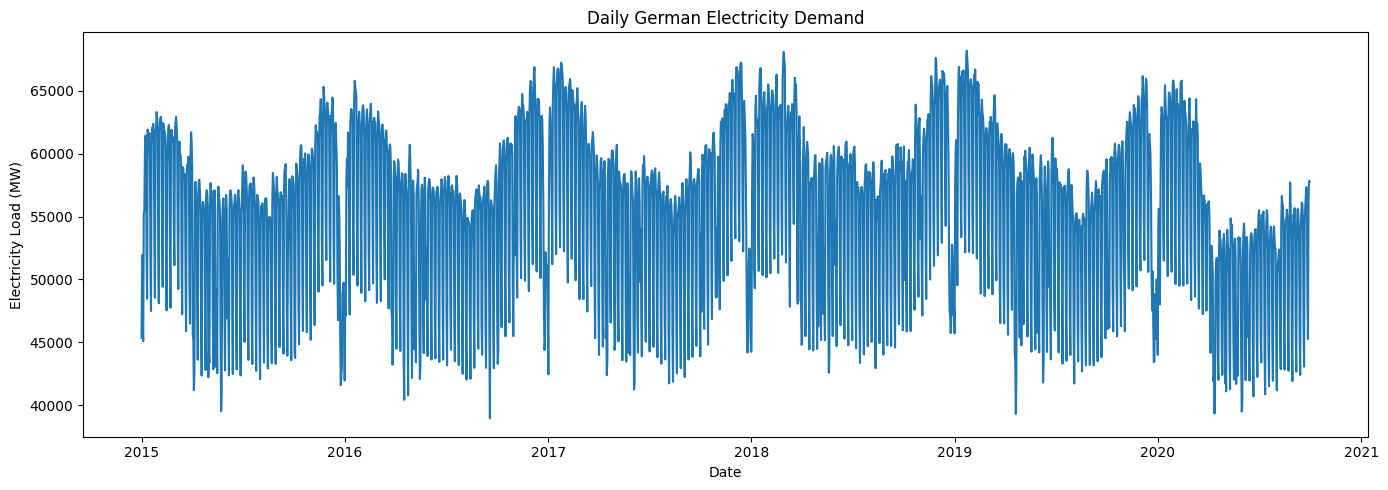

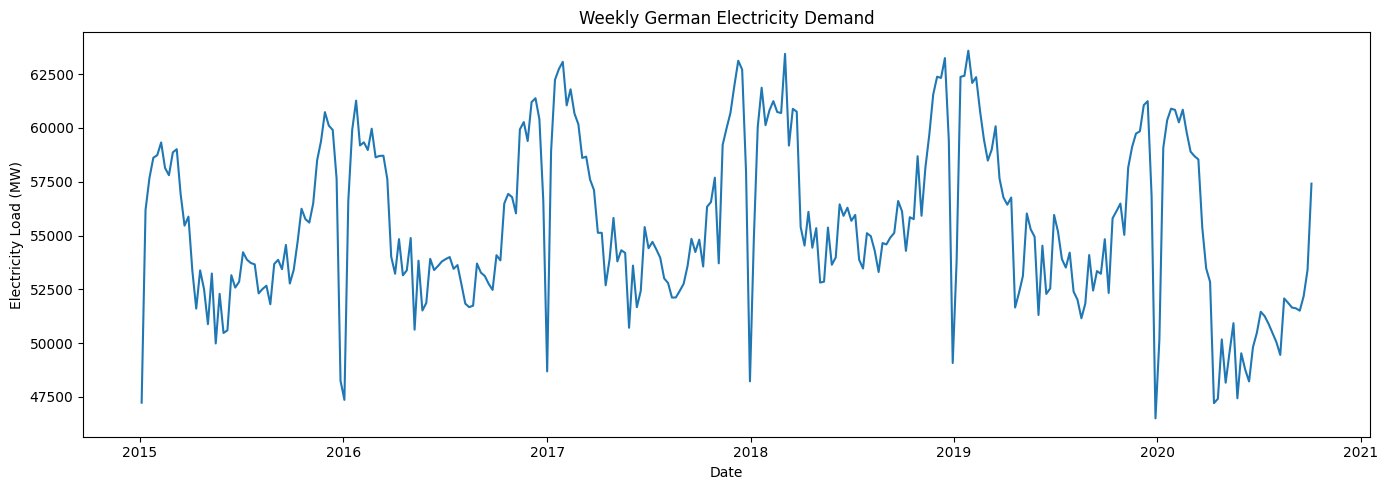


Data cleaning and resampling completed correctly.


In [4]:
# DATA CLEANING AND RESAMPLING FOR GERMAN ELECTRICITY DEMAND


import pandas as pd
import matplotlib.pyplot as plt
import os


# 1. Load the dataset


file_path = "time_series_60min_singleindex.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Raw dataset shape:", df_raw.shape)


# 2. Check date range of raw dataset

print("\nRaw date range:")
print("First date:", df_raw["utc_timestamp"].min())
print("Last date :", df_raw["utc_timestamp"].max())


# 3. Identify Germany demand column


germany_columns = [col for col in df_raw.columns if col.startswith("DE")]

print("\nGermany-related columns:")
for col in germany_columns:
    print(col)

germany_actual_load_columns = [
    col for col in df_raw.columns
    if col.startswith("DE")
    and "load_actual" in col.lower()
]

print("\nPossible German actual load columns:")
print(germany_actual_load_columns)

# Use national Germany demand column
load_column = "DE_load_actual_entsoe_transparency"

if load_column not in df_raw.columns:
    raise ValueError("German national demand column not found. Check column names.")

print("\nSelected German demand column:", load_column)


# 4. Keep only timestamp and German load column


df = df_raw[["utc_timestamp", load_column]].copy()

df.rename(columns={
    "utc_timestamp": "Date",
    load_column: "Load"
}, inplace=True)


# 5. Convert Date to datetime and set index

df["Date"] = pd.to_datetime(df["Date"], utc=True)
df.set_index("Date", inplace=True)


# 6. From 1 Jan 2015 to Oct 2020

df = df.loc["2015-01-01":"2020-10-31"].copy()

print("\nFiltered date range:")
print("First date:", df.index.min())
print("Last date :", df.index.max())


# 7. Sort index


df = df.sort_index()


# 8. Check duplicate timestamps

duplicate_timestamps = df.index.duplicated().sum()
print("\nDuplicate timestamps:", duplicate_timestamps)

if duplicate_timestamps > 0:
    df = df[~df.index.duplicated(keep="first")]


# 9. Check missing values

print("\nMissing values before treatment:")
print(df.isnull().sum())

# Time-based interpolation for continuous time series
df["Load"] = df["Load"].interpolate(method="time")
df["Load"] = df["Load"].ffill()
df["Load"] = df["Load"].bfill()

print("\nMissing values after treatment:")
print(df.isnull().sum())


# 10. Create daily and weekly datasets

daily_load = df.resample("D").mean()
weekly_load = df.resample("W").mean()


# 11. Print final checks


print("\nFinal hourly data:")
print(df.head())
print(df.tail())
print("Hourly shape:", df.shape)

print("\nFinal daily data:")
print(daily_load.head())
print(daily_load.tail())
print("Daily shape:", daily_load.shape)

print("\nFinal weekly data:")
print(weekly_load.head())
print(weekly_load.tail())
print("Weekly shape:", weekly_load.shape)


# 12. Save cleaned data


os.makedirs("processed_data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

df.to_csv("processed_data/hourly_germany_load.csv")
daily_load.to_csv("processed_data/daily_germany_load.csv")
weekly_load.to_csv("processed_data/weekly_germany_load.csv")

print("\nCleaned datasets saved successfully.")


# 13. Plot hourly, daily and weekly data

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Load"])
plt.title("Hourly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/hourly_german_electricity_demand.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(daily_load.index, daily_load["Load"])
plt.title("Daily German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/daily_german_electricity_demand.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(weekly_load.index, weekly_load["Load"])
plt.title("Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/weekly_german_electricity_demand.png", dpi=300)
plt.show()

print("\nData cleaning and resampling completed correctly.")

In [5]:
df
daily_load
weekly_load

,Load
Date,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762
...,...
2020-09-06 00:00:00+00:00,51617.744048
2020-09-13 00:00:00+00:00,51507.630952
2020-09-20 00:00:00+00:00,52181.327381


Hourly shape: (50400, 1)
Daily shape : (2100, 1)
Weekly shape: (301, 1)

HOURLY SUMMARY STATISTICS
count    50400.000000
mean     55492.468552
std      10015.431042
min      31307.000000
25%      47106.000000
50%      55092.000000
75%      64309.250000
max      77549.000000
Name: Load, dtype: float64

DAILY SUMMARY STATISTICS
count     2100.000000
mean     55492.468552
std       6601.474342
min      38952.666667
25%      50413.447917
50%      56776.916667
75%      60430.093750
max      68183.583333
Name: Load, dtype: float64

WEEKLY SUMMARY STATISTICS
count      301.000000
mean     55484.350477
std       3762.742475
min      46505.309524
25%      52845.267857
50%      54858.434524
75%      58688.470238
max      63587.011905
Name: Load, dtype: float64

Missing values:
Hourly: 0
Daily : 0
Weekly: 0

Duplicate timestamps:
Hourly: 0
Daily : 0
Weekly: 0


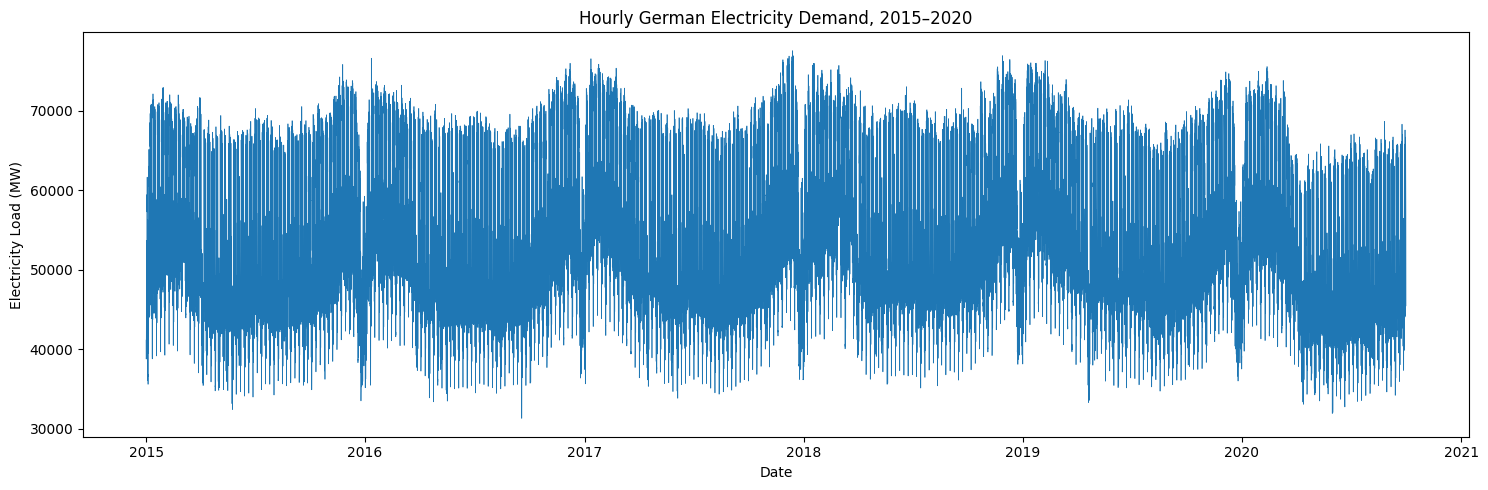

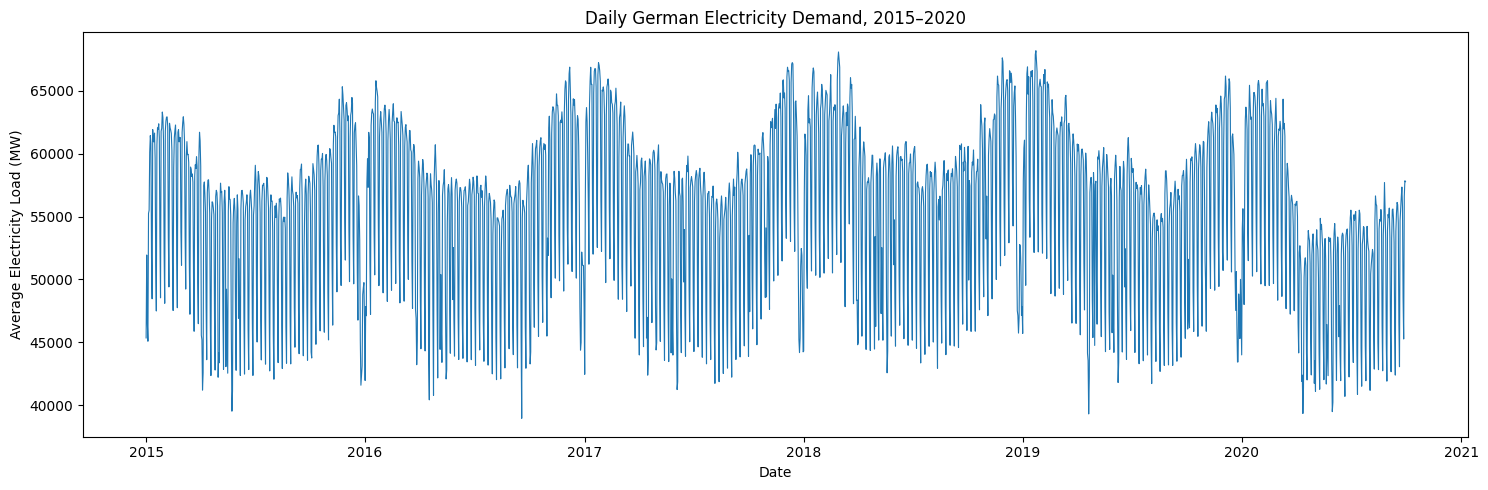

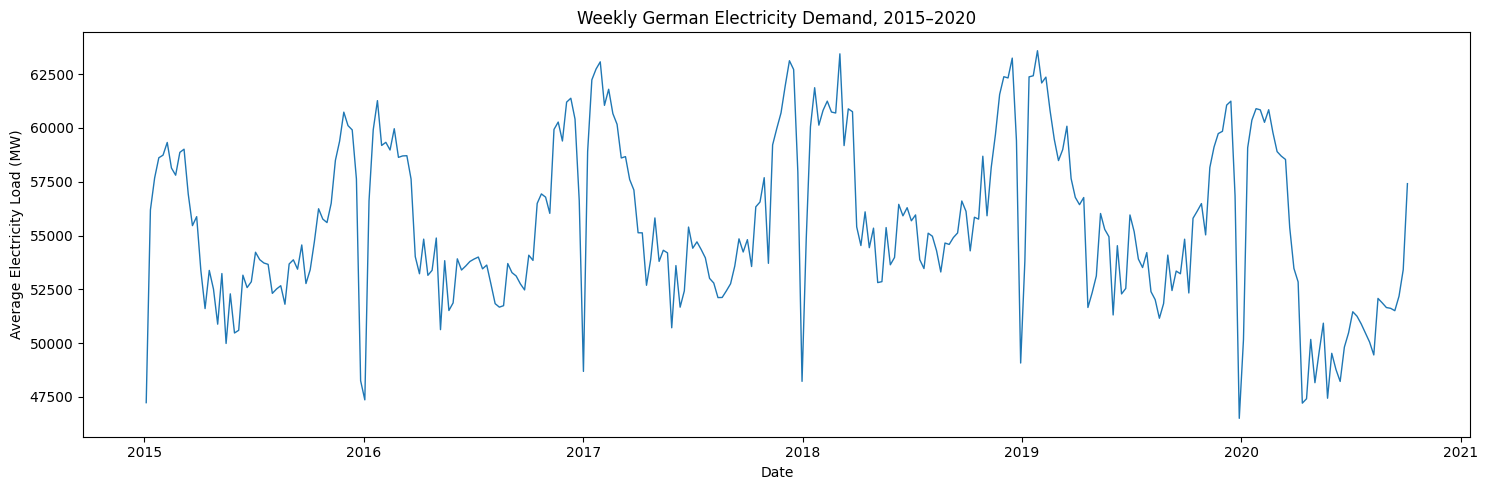

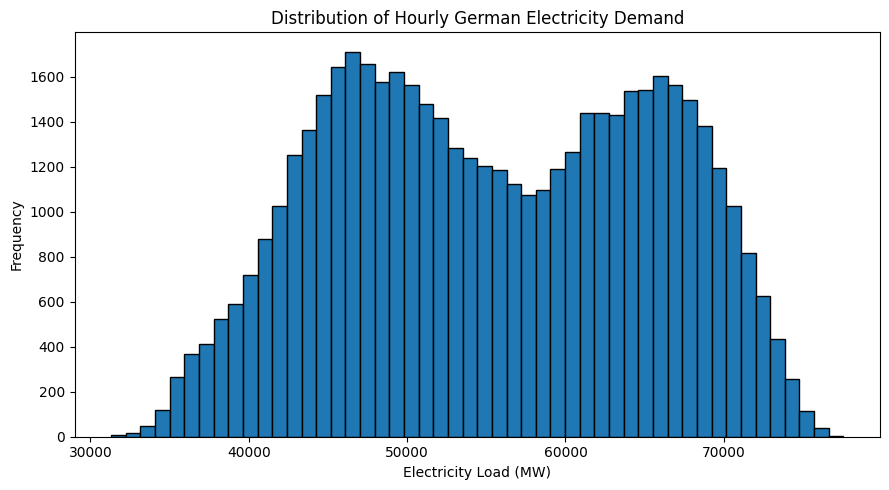

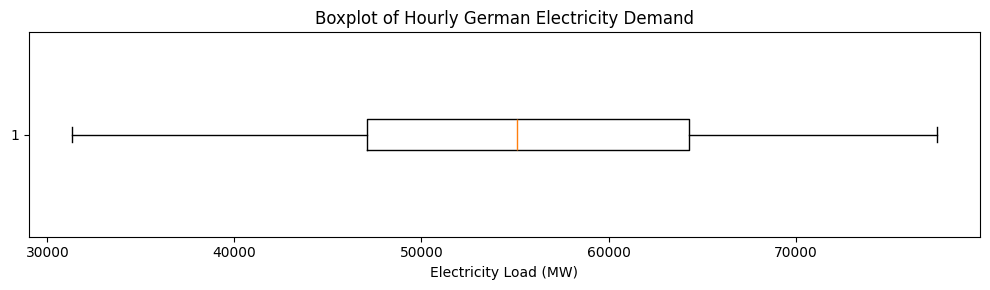

/tmp/ipykernel_750/986032764.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(monthly_groups, labels=month_labels)


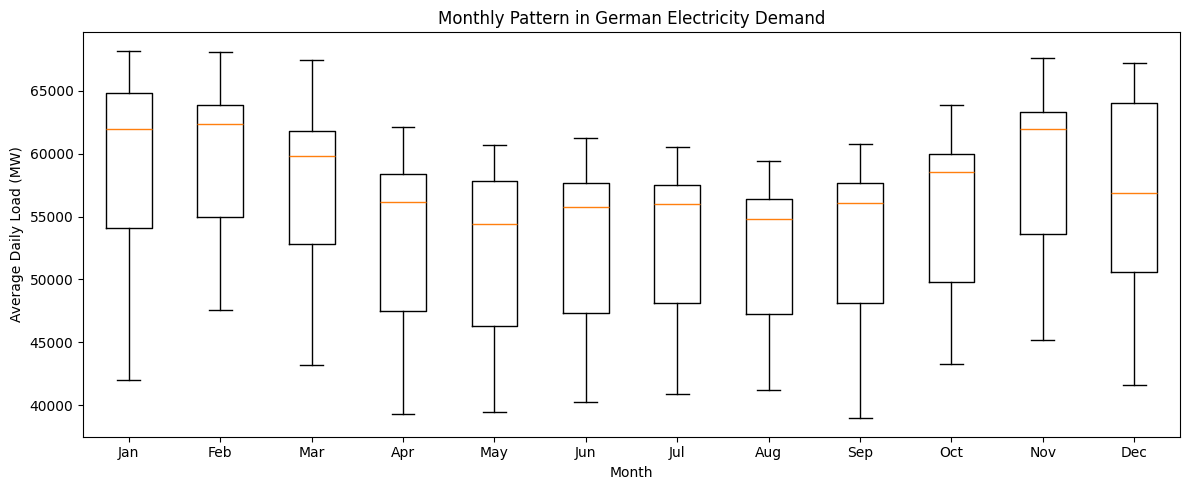

/tmp/ipykernel_750/986032764.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weekday_groups, labels=weekday_labels)


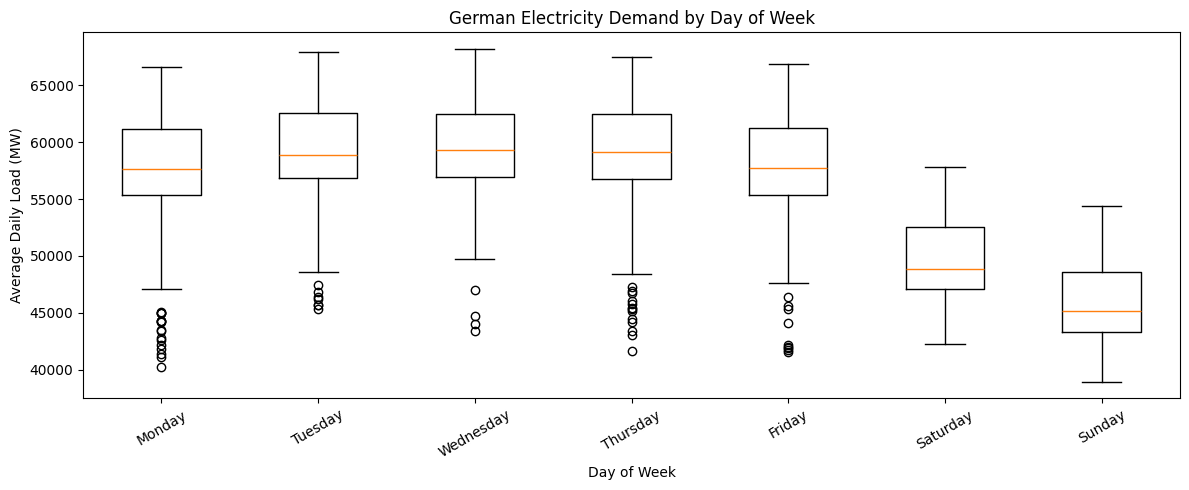

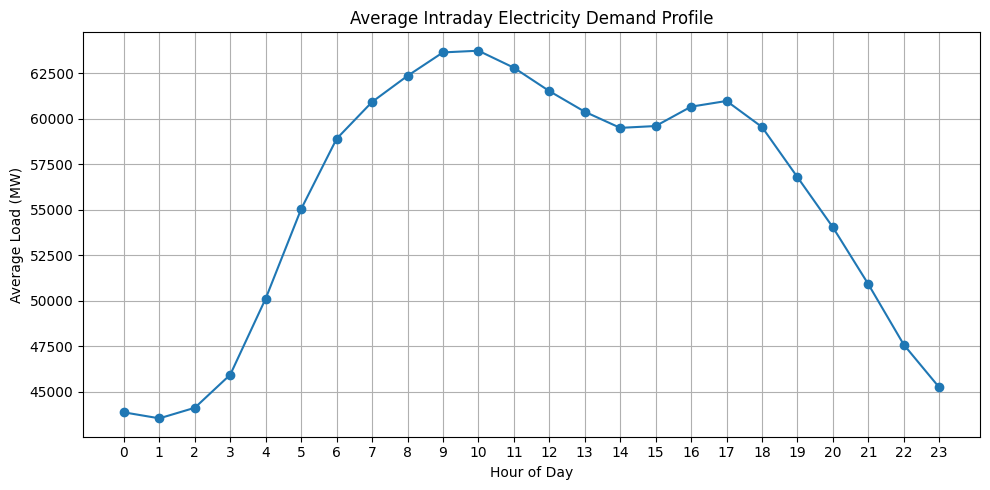

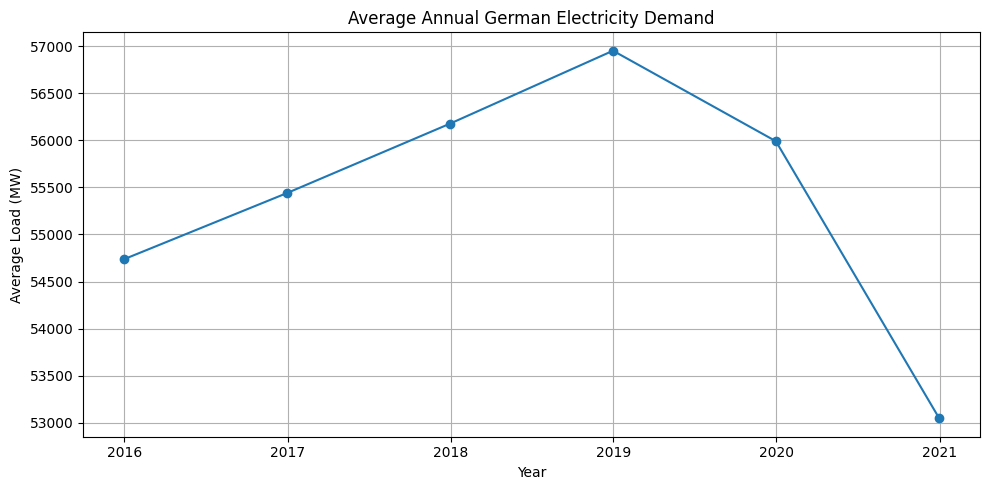

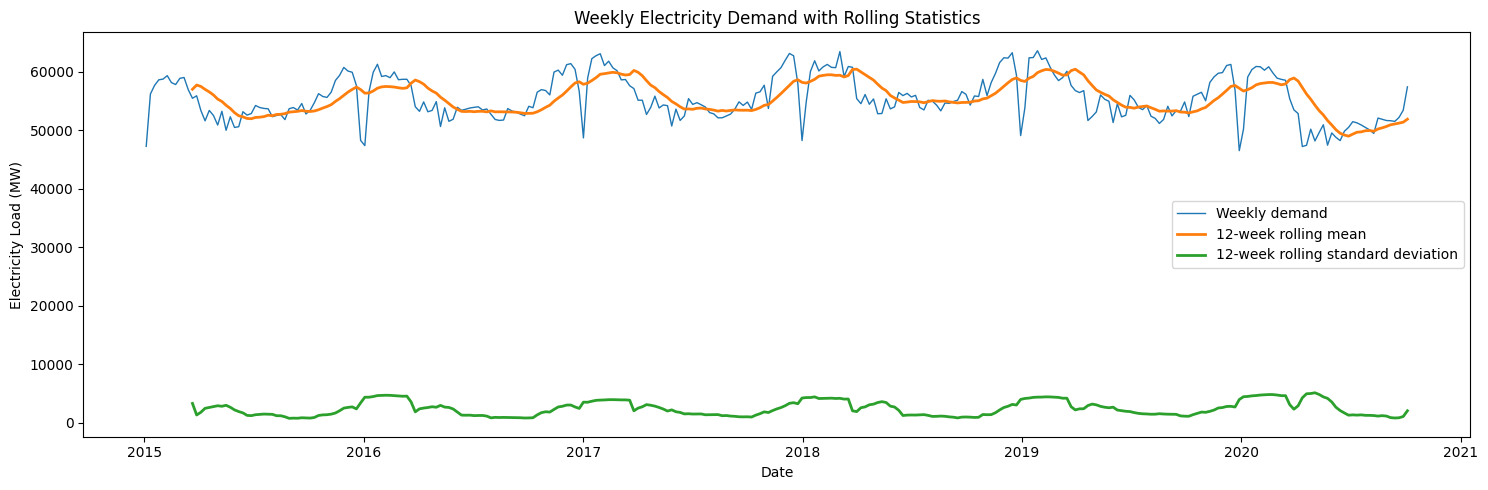

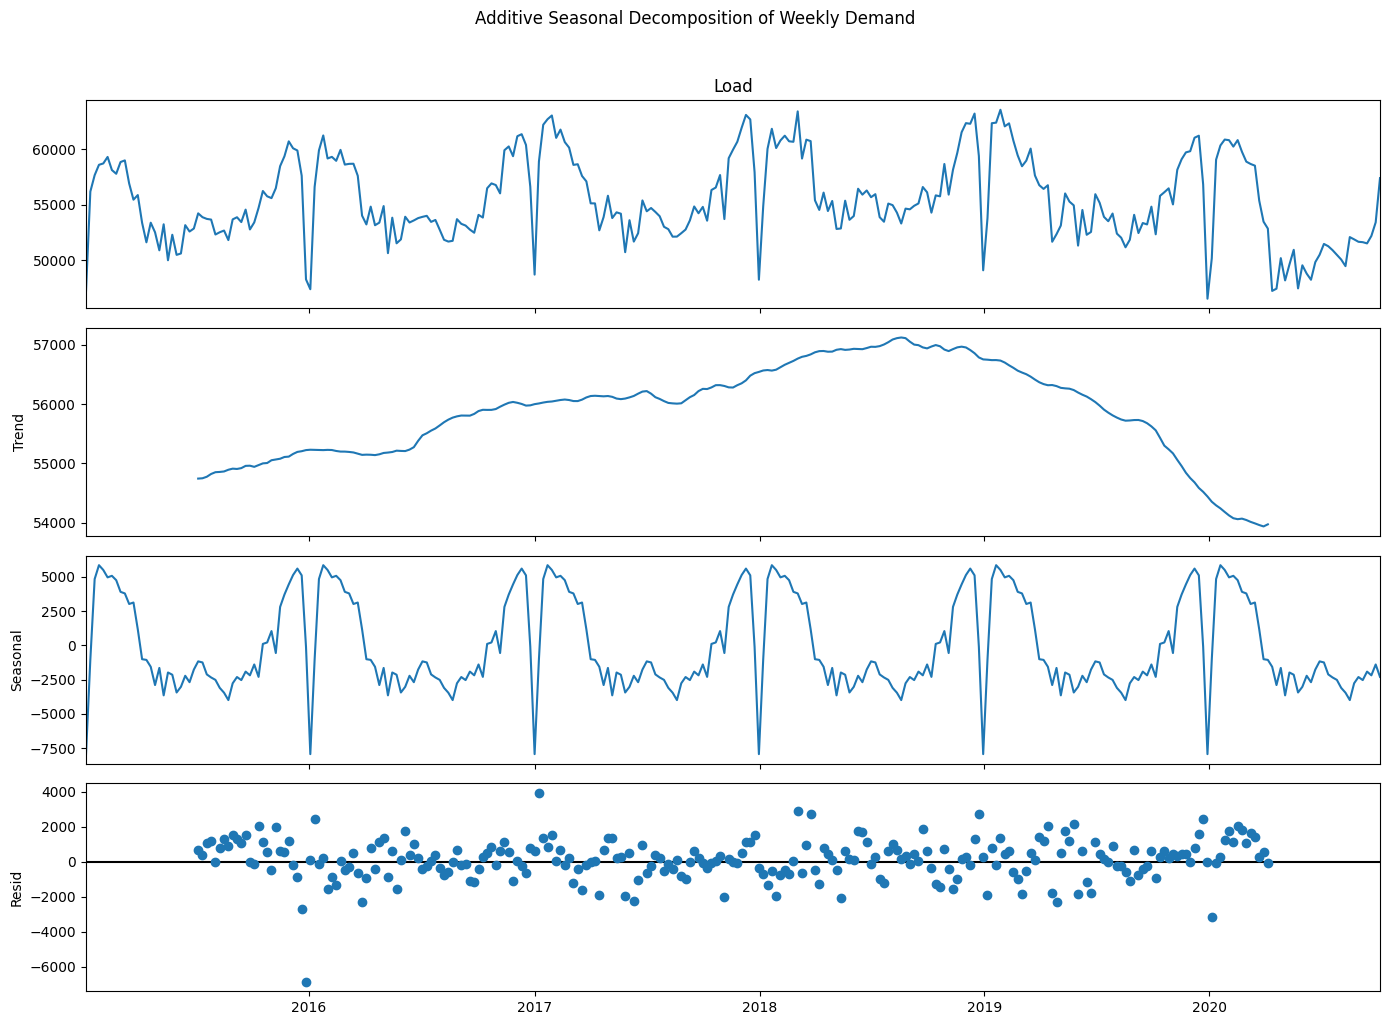

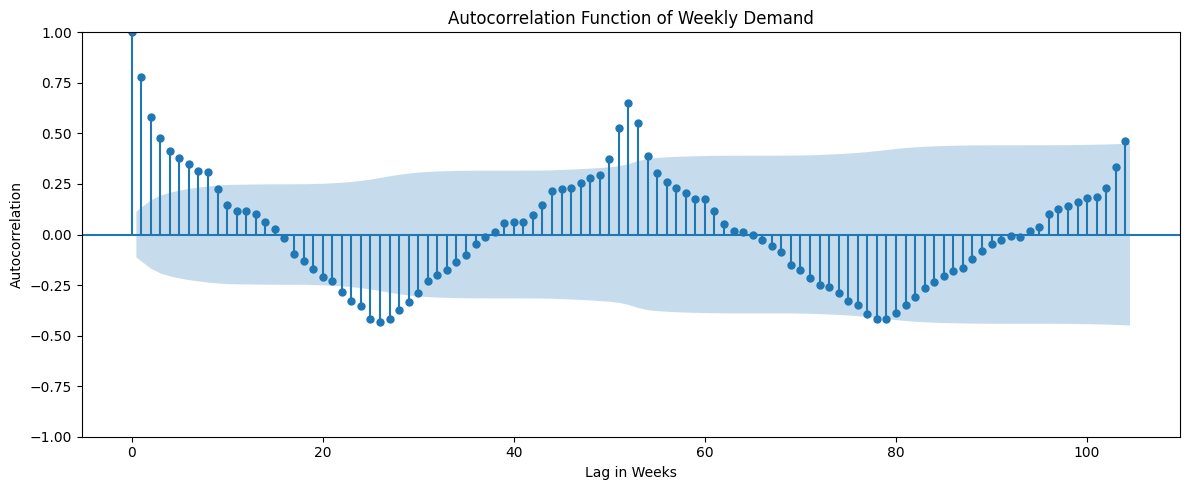

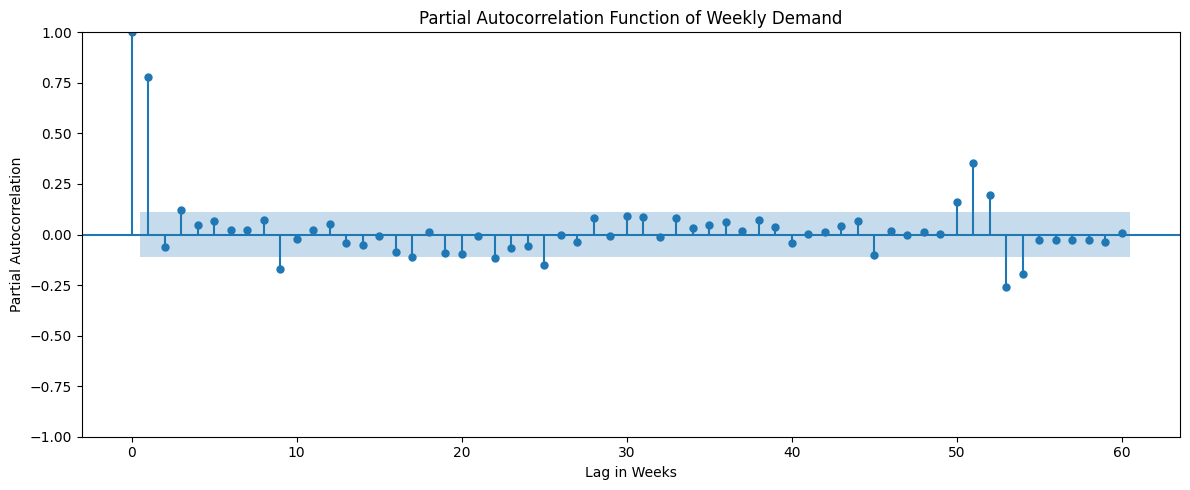


AUGMENTED DICKEY-FULLER TEST
ADF statistic             : -4.0475
P-value                   : 0.001181
Number of lags used       : 8
Number of observations    : 292

Critical values:
1%: -3.4529
5%: -2.8715
10%: -2.5721

Conclusion:
Reject the null hypothesis of a unit root.
The weekly electricity-demand series appears stationary.


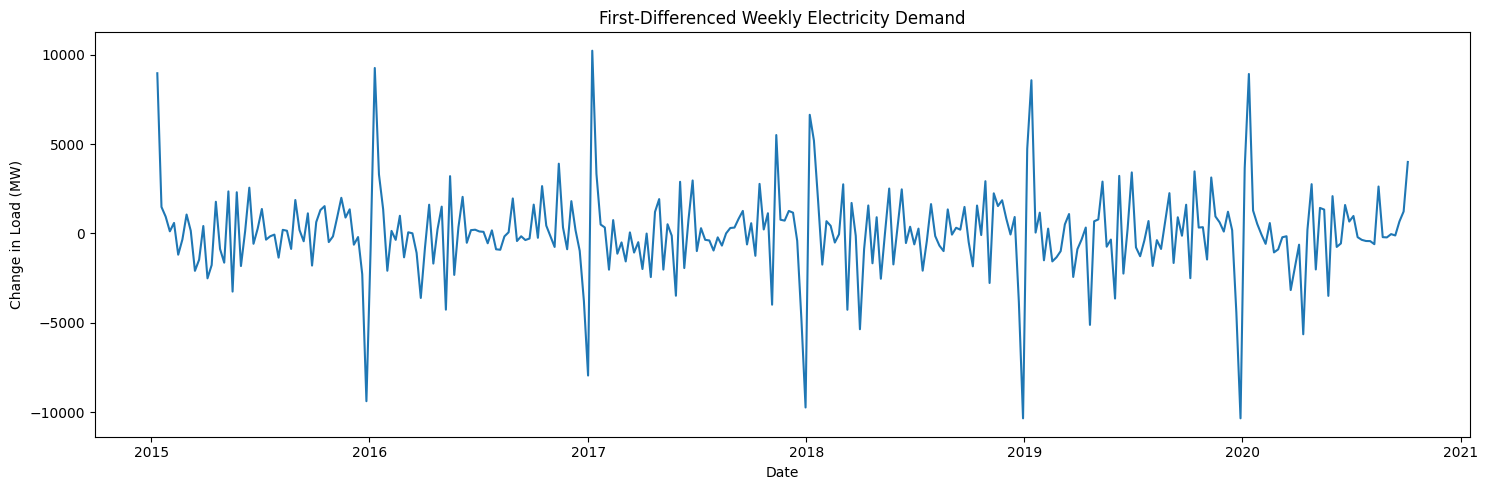


ADF TEST AFTER FIRST DIFFERENCING
ADF statistic : -7.0693
P-value       : 0.000000

The first-differenced series appears stationary.


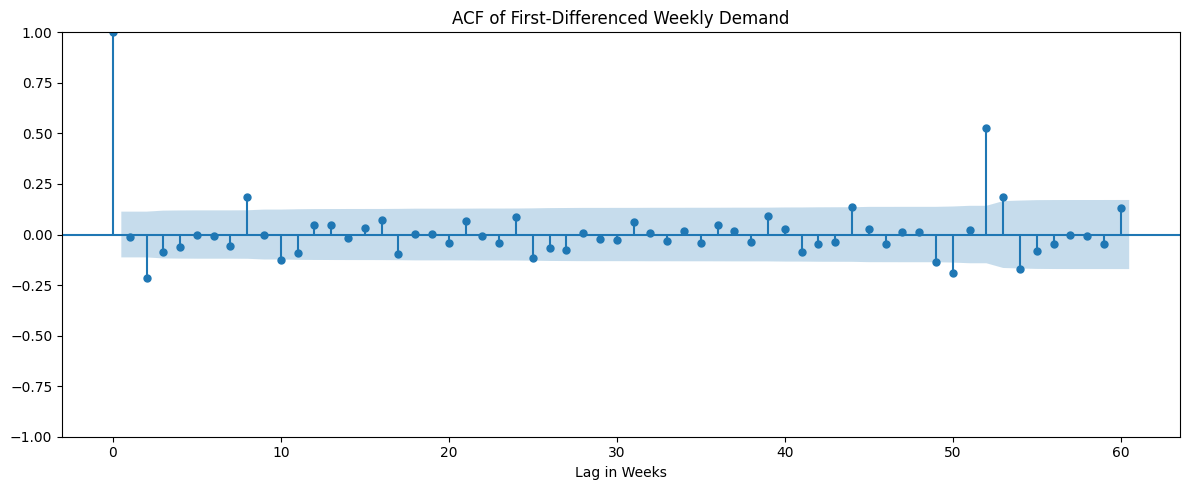

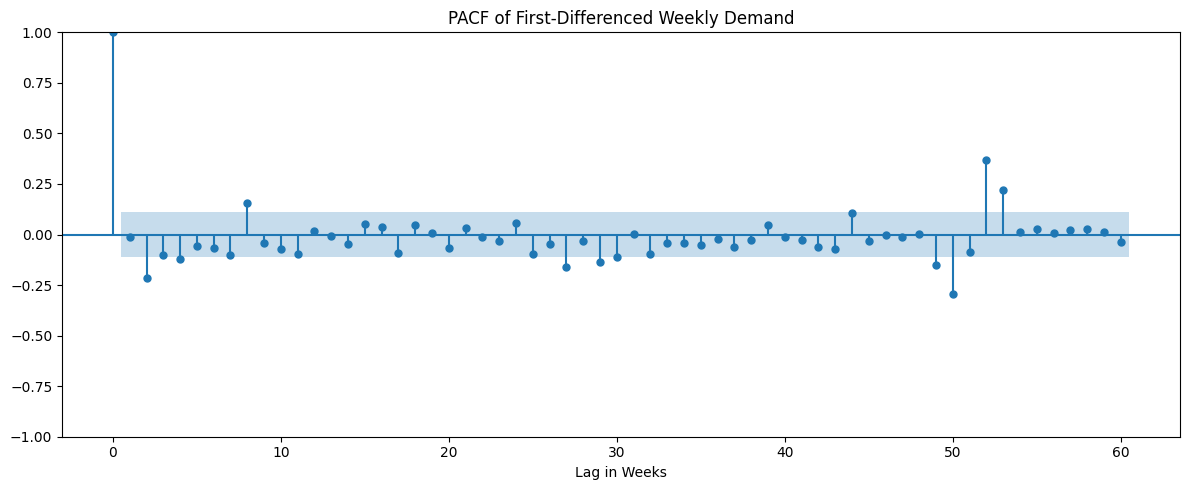


EDA and stationarity analysis completed successfully.
All figures were saved in the 'figures' folder.


In [6]:
# EXPLORATORY DATA ANALYSIS (EDA)
# German Electricity Demand

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


# 1. Reuse cleaned datasets from preprocessing


hourly = df.copy()
daily = daily_load.copy()
weekly = weekly_load.copy()

print("Hourly shape:", hourly.shape)
print("Daily shape :", daily.shape)
print("Weekly shape:", weekly.shape)

# Create a folder to save figures
os.makedirs("figures", exist_ok=True)

# 2. Summary statistics

print("\n" + "=" * 60)
print("HOURLY SUMMARY STATISTICS")
print("=" * 60)
print(hourly["Load"].describe())

print("\n" + "=" * 60)
print("DAILY SUMMARY STATISTICS")
print("=" * 60)
print(daily["Load"].describe())

print("\n" + "=" * 60)
print("WEEKLY SUMMARY STATISTICS")
print("=" * 60)
print(weekly["Load"].describe())

# 3. Missing-value and duplicate-timestamp checks

print("\nMissing values:")
print("Hourly:", hourly["Load"].isna().sum())
print("Daily :", daily["Load"].isna().sum())
print("Weekly:", weekly["Load"].isna().sum())

print("\nDuplicate timestamps:")
print("Hourly:", hourly.index.duplicated().sum())
print("Daily :", daily.index.duplicated().sum())
print("Weekly:", weekly.index.duplicated().sum())

# 4. Hourly electricity demand plot

plt.figure(figsize=(15, 5))
plt.plot(hourly.index, hourly["Load"], linewidth=0.5)
plt.title("Hourly German Electricity Demand, 2015–2020")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/01_hourly_electricity_demand.png", dpi=300)
plt.show()

# 5. Daily electricity demand plot

plt.figure(figsize=(15, 5))
plt.plot(daily.index, daily["Load"], linewidth=0.8)
plt.title("Daily German Electricity Demand, 2015–2020")
plt.xlabel("Date")
plt.ylabel("Average Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/02_daily_electricity_demand.png", dpi=300)
plt.show()

# 6. Weekly electricity demand plot

plt.figure(figsize=(15, 5))
plt.plot(weekly.index, weekly["Load"], linewidth=1)
plt.title("Weekly German Electricity Demand, 2015–2020")
plt.xlabel("Date")
plt.ylabel("Average Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/03_weekly_electricity_demand.png", dpi=300)
plt.show()

# 7. Distribution of hourly demand

plt.figure(figsize=(9, 5))
plt.hist(hourly["Load"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Hourly German Electricity Demand")
plt.xlabel("Electricity Load (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/04_hourly_load_distribution.png", dpi=300)
plt.show()

# 8. Boxplot of hourly demand

plt.figure(figsize=(10, 3))
plt.boxplot(hourly["Load"].dropna(), vert=False)
plt.title("Boxplot of Hourly German Electricity Demand")
plt.xlabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/05_hourly_load_boxplot.png", dpi=300)
plt.show()

# 9. Monthly seasonal pattern

monthly_analysis = daily.copy()
monthly_analysis["Month"] = monthly_analysis.index.month

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_groups = [
    monthly_analysis.loc[
        monthly_analysis["Month"] == month, "Load"
    ].dropna()
    for month in range(1, 13)
]

plt.figure(figsize=(12, 5))
plt.boxplot(monthly_groups, labels=month_labels)
plt.title("Monthly Pattern in German Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Average Daily Load (MW)")
plt.tight_layout()
plt.savefig("figures/06_monthly_demand_pattern.png", dpi=300)
plt.show()

# 10. Day-of-week pattern

weekday_analysis = daily.copy()
weekday_analysis["DayOfWeek"] = weekday_analysis.index.dayofweek

weekday_labels = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_groups = [
    weekday_analysis.loc[
        weekday_analysis["DayOfWeek"] == day, "Load"
    ].dropna()
    for day in range(7)
]

plt.figure(figsize=(12, 5))
plt.boxplot(weekday_groups, labels=weekday_labels)
plt.title("German Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Load (MW)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/07_day_of_week_pattern.png", dpi=300)
plt.show()

# 11. Average hourly demand profile

hourly_profile = hourly.copy()
hourly_profile["Hour"] = hourly_profile.index.hour

average_hourly_profile = hourly_profile.groupby("Hour")["Load"].mean()

plt.figure(figsize=(10, 5))
plt.plot(
    average_hourly_profile.index,
    average_hourly_profile.values,
    marker="o"
)
plt.title("Average Intraday Electricity Demand Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/08_average_hourly_profile.png", dpi=300)
plt.show()

# 12. Average annual demand trend

yearly = daily.resample("YE").mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly["Load"], marker="o")
plt.title("Average Annual German Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Average Load (MW)")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/09_annual_demand_trend.png", dpi=300)
plt.show()

# 13. Rolling mean and rolling standard deviation

rolling_window = 12

rolling_mean = weekly["Load"].rolling(
    window=rolling_window
).mean()

rolling_std = weekly["Load"].rolling(
    window=rolling_window
).std()

plt.figure(figsize=(15, 5))
plt.plot(
    weekly.index,
    weekly["Load"],
    label="Weekly demand",
    linewidth=1
)
plt.plot(
    rolling_mean.index,
    rolling_mean,
    label="12-week rolling mean",
    linewidth=2
)
plt.plot(
    rolling_std.index,
    rolling_std,
    label="12-week rolling standard deviation",
    linewidth=2
)
plt.title("Weekly Electricity Demand with Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/10_weekly_rolling_statistics.png", dpi=300)
plt.show()

# 14. Seasonal decomposition of weekly demand

decomposition = seasonal_decompose(
    weekly["Load"].dropna(),
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle(
    "Additive Seasonal Decomposition of Weekly Demand",
    y=1.02
)
plt.tight_layout()
plt.savefig("figures/11_weekly_seasonal_decomposition.png", dpi=300)
plt.show()

# 15. ACF plot

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    weekly["Load"].dropna(),
    lags=104,
    ax=ax
)

ax.set_title("Autocorrelation Function of Weekly Demand")
ax.set_xlabel("Lag in Weeks")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("figures/12_weekly_acf.png", dpi=300)
plt.show()

# 16. PACF plot

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    weekly["Load"].dropna(),
    lags=60,
    method="ywm",
    ax=ax
)

ax.set_title("Partial Autocorrelation Function of Weekly Demand")
ax.set_xlabel("Lag in Weeks")
ax.set_ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.savefig("figures/13_weekly_pacf.png", dpi=300)
plt.show()

# 17. Augmented Dickey-Fuller stationarity test

adf_result = adfuller(
    weekly["Load"].dropna(),
    autolag="AIC"
)

print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)

print(f"ADF statistic             : {adf_result[0]:.4f}")
print(f"P-value                   : {adf_result[1]:.6f}")
print(f"Number of lags used       : {adf_result[2]}")
print(f"Number of observations    : {adf_result[3]}")

print("\nCritical values:")
for significance_level, critical_value in adf_result[4].items():
    print(
        f"{significance_level}: "
        f"{critical_value:.4f}"
    )

if adf_result[1] < 0.05:
    print("\nConclusion:")
    print("Reject the null hypothesis of a unit root.")
    print("The weekly electricity-demand series appears stationary.")
else:
    print("\nConclusion:")
    print("Fail to reject the null hypothesis of a unit root.")
    print("The weekly series appears non-stationary.")
    print("Differencing should be investigated before SARIMA modelling.")

# 18. First-differenced weekly series

weekly_diff_1 = weekly["Load"].diff().dropna()

plt.figure(figsize=(15, 5))
plt.plot(weekly_diff_1.index, weekly_diff_1)
plt.title("First-Differenced Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Change in Load (MW)")
plt.tight_layout()
plt.savefig("figures/14_first_differenced_weekly_demand.png", dpi=300)
plt.show()

# 19. ADF test after first differencing

adf_diff_result = adfuller(
    weekly_diff_1,
    autolag="AIC"
)

print("\n" + "=" * 60)
print("ADF TEST AFTER FIRST DIFFERENCING")
print("=" * 60)

print(f"ADF statistic : {adf_diff_result[0]:.4f}")
print(f"P-value       : {adf_diff_result[1]:.6f}")

if adf_diff_result[1] < 0.05:
    print("\nThe first-differenced series appears stationary.")
else:
    print("\nThe first-differenced series still appears non-stationary.")

# 20. ACF and PACF of first-differenced series

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    weekly_diff_1,
    lags=60,
    ax=ax
)

ax.set_title("ACF of First-Differenced Weekly Demand")
ax.set_xlabel("Lag in Weeks")
plt.tight_layout()
plt.savefig("figures/15_differenced_weekly_acf.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    weekly_diff_1,
    lags=60,
    method="ywm",
    ax=ax
)

ax.set_title("PACF of First-Differenced Weekly Demand")
ax.set_xlabel("Lag in Weeks")
plt.tight_layout()
plt.savefig("figures/16_differenced_weekly_pacf.png", dpi=300)
plt.show()

print("\nEDA and stationarity analysis completed successfully.")
print("All figures were saved in the 'figures' folder.")

Total weekly observations: 301

Training observations : 197
Testing observations  : 104

Training period
2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00

Testing period
2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00


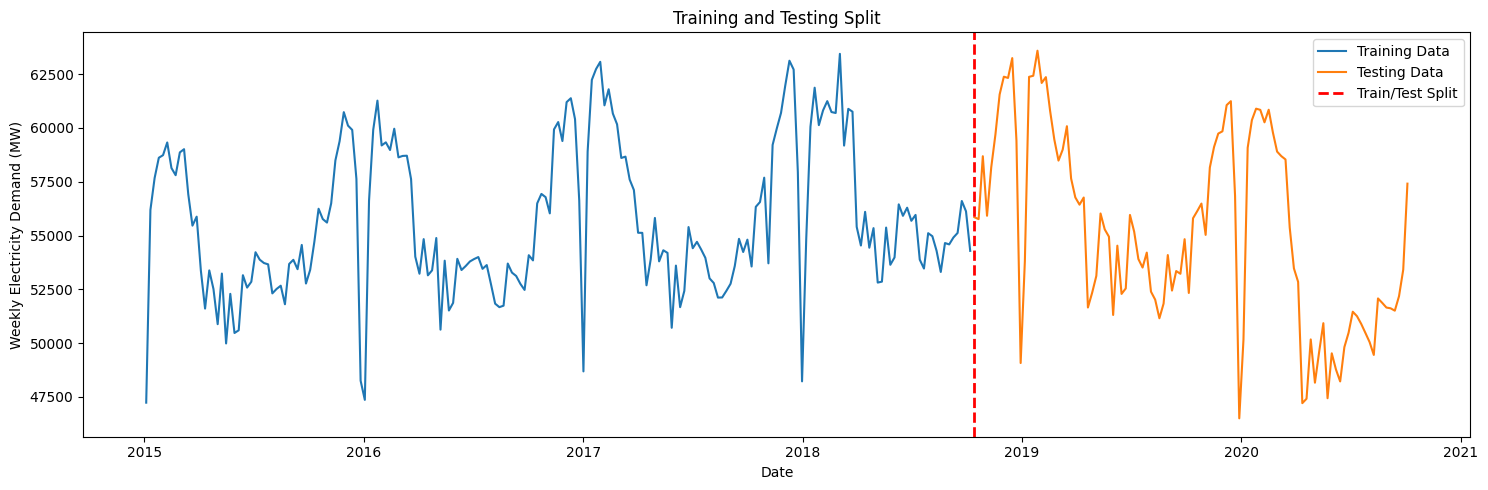

In [7]:
# TRAIN-TEST SPLIT

data = weekly.copy()

print("Total weekly observations:", len(data))

test_size = 104  # using two years data

train = data.iloc[:-test_size]

test = data.iloc[-test_size:]

print("\nTraining observations :", len(train))
print("Testing observations  :", len(test))

print("\nTraining period")
print(train.index.min(), "to", train.index.max())

print("\nTesting period")
print(test.index.min(), "to", test.index.max())

plt.figure(figsize=(15,5))

# Visualising split

plt.plot(train.index, train["Load"], label="Training Data")

plt.plot(test.index, test["Load"], label="Testing Data")

plt.axvline(
    x=test.index[0],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Train/Test Split"
)

plt.title("Training and Testing Split")

plt.xlabel("Date")

plt.ylabel("Weekly Electricity Demand (MW)")

plt.legend()

plt.tight_layout()

plt.show()

Training observations: 197
Testing observations : 104
Training period       : 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Testing period        : 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00

MEAN FORECAST
Training mean: 55650.55
MAE : 3788.83
RMSE: 4397.30
MAPE: 6.97%

NAIVE FORECAST
Last training value: 54287.06
MAE : 3783.20
RMSE: 4459.11
MAPE: 6.79%

SEASONAL NAIVE FORECAST
Seasonal period: 52 weeks
MAE : 2318.52
RMSE: 3006.76
MAPE: 4.41%

DRIFT FORECAST
Weekly drift: 35.99 MW
MAE : 4339.89
RMSE: 5117.96
MAPE: 8.05%

BENCHMARK MODEL COMPARISON
         Model     MAE    RMSE  MAPE (%)
Seasonal Naive 2318.52 3006.76      4.41
          Mean 3788.83 4397.30      6.97
         Naive 3783.20 4459.11      6.79
         Drift 4339.89 5117.96      8.05


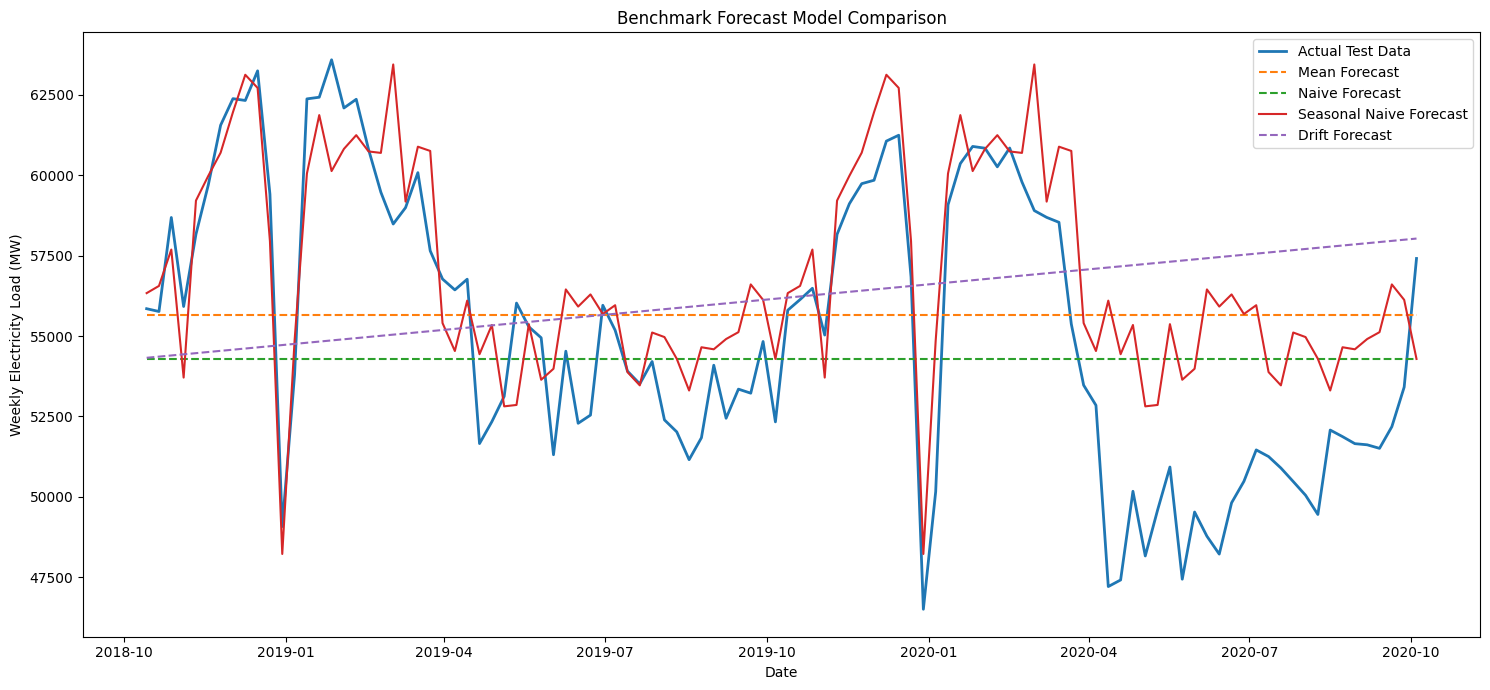

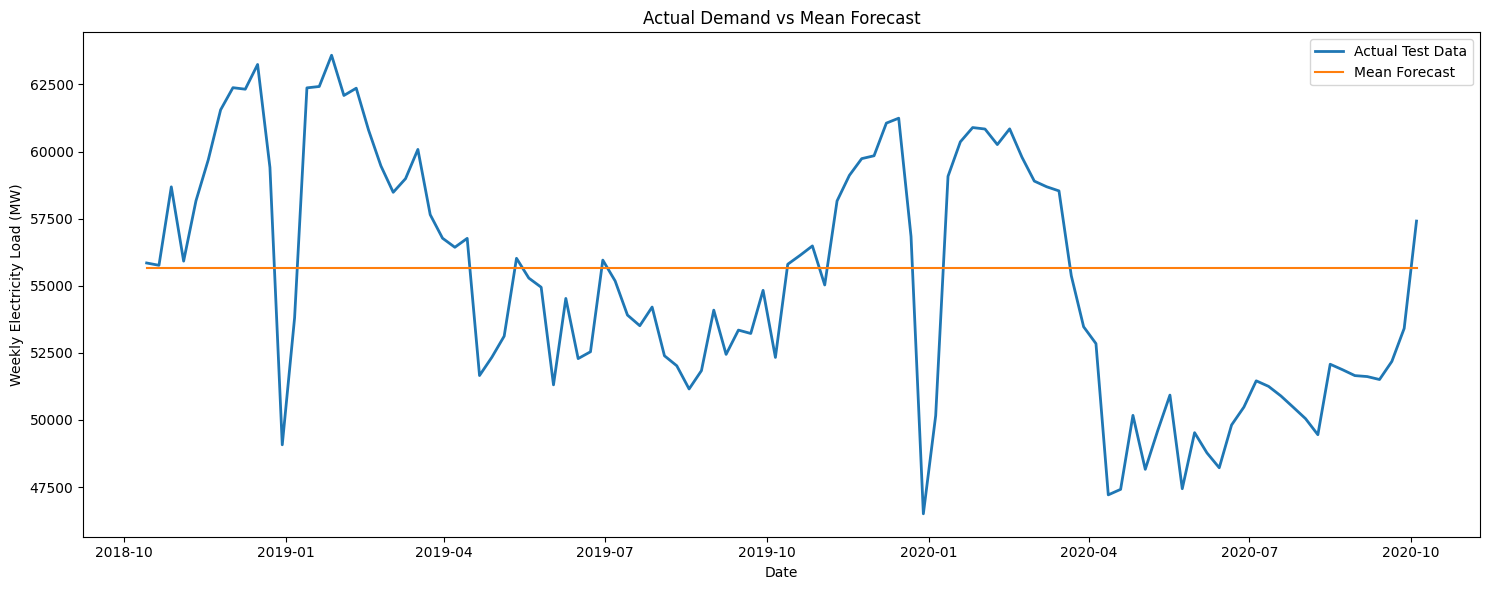

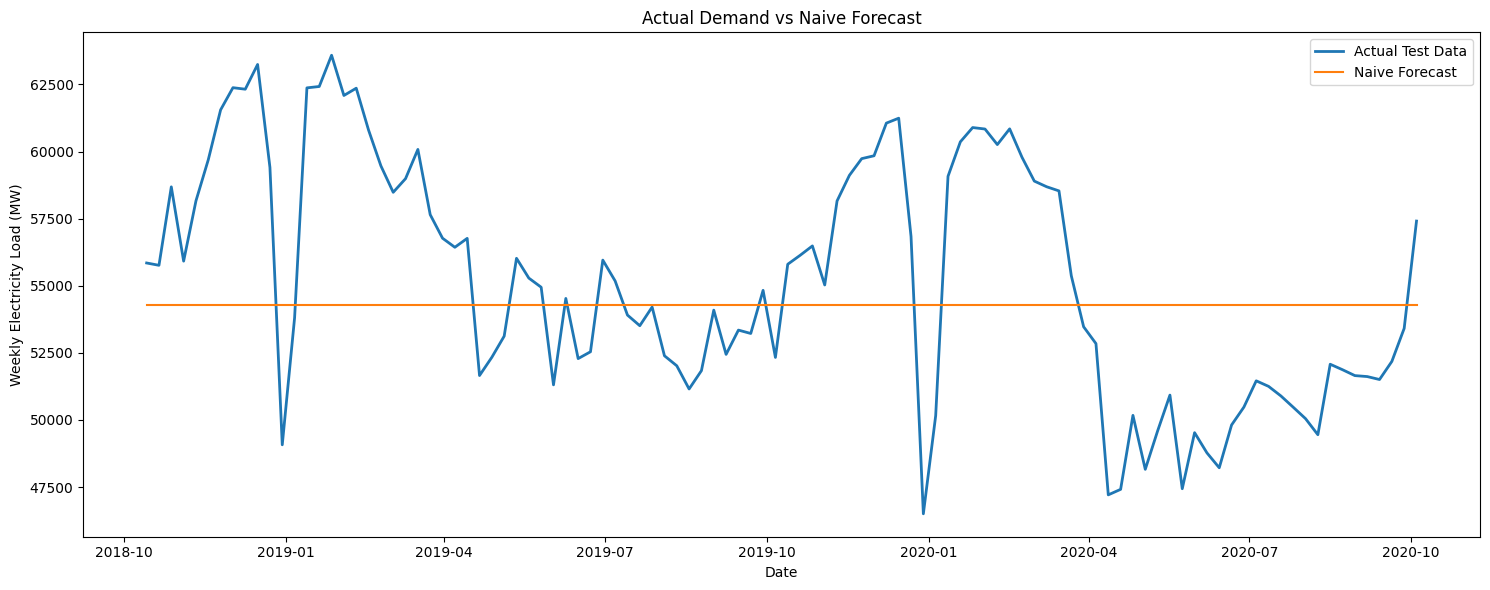

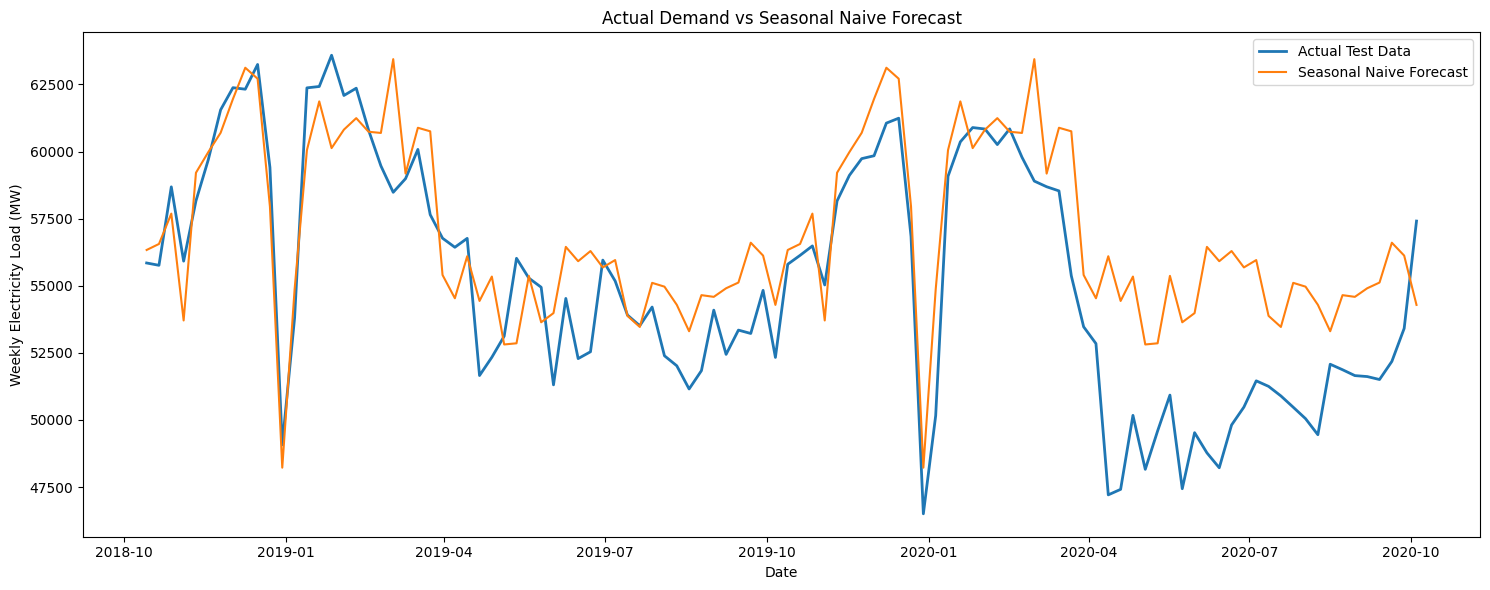

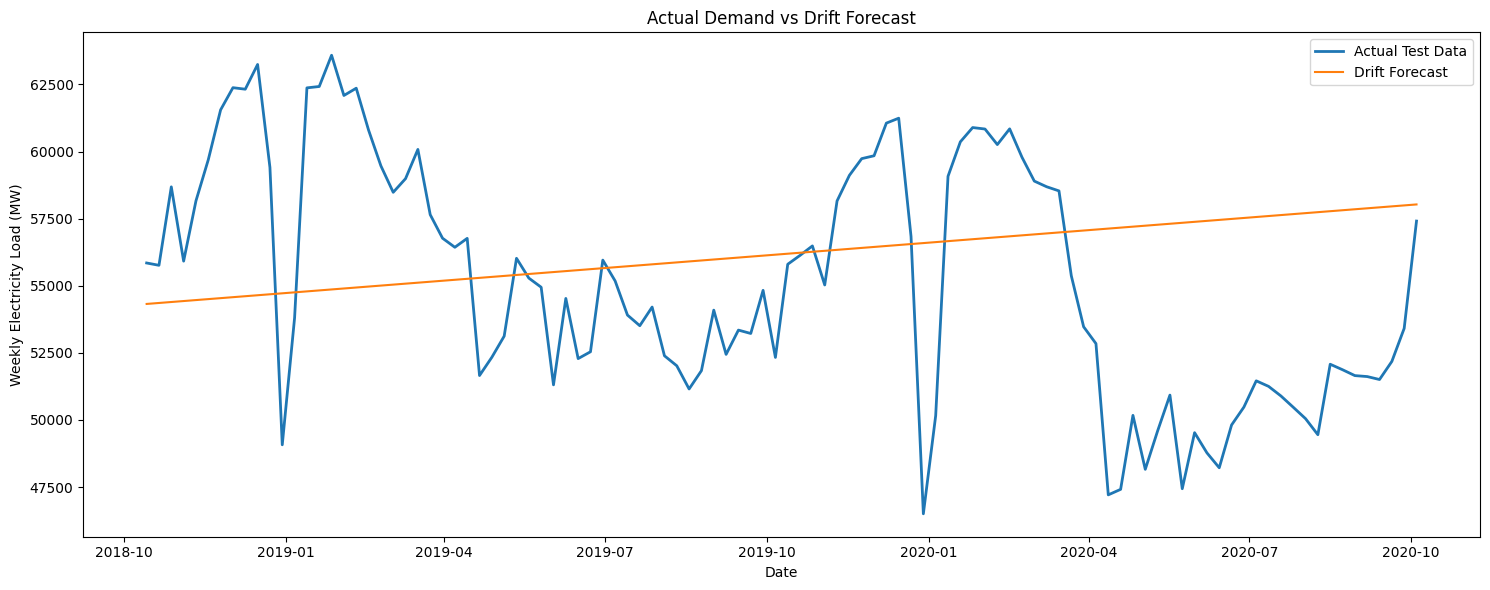

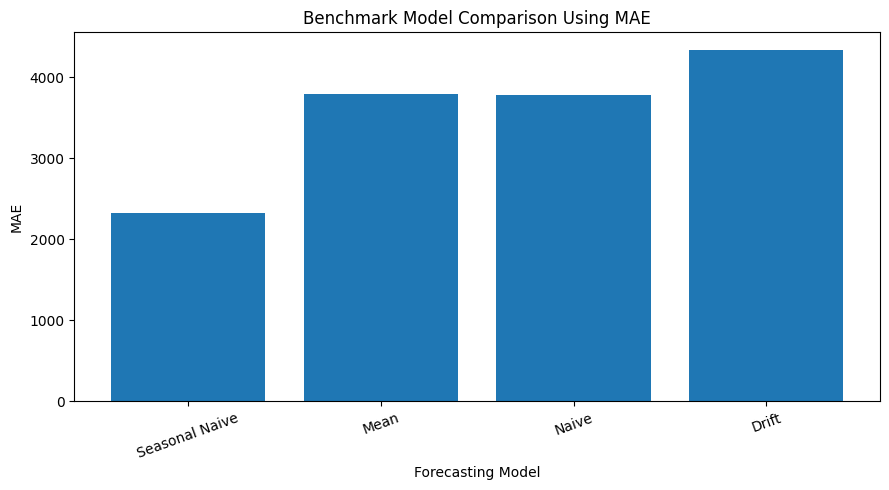

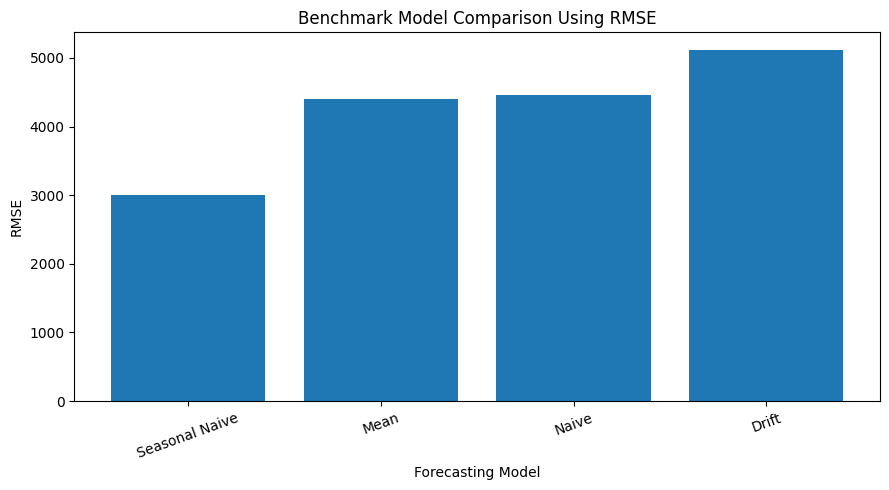

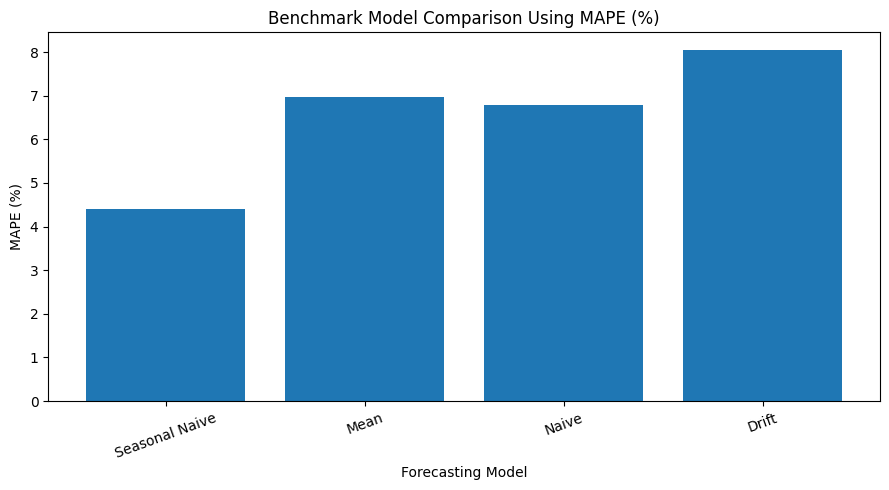

In [8]:
# BENCHMARK FORECASTING MODELS
# Mean, Naive, Seasonal Naive and Drift

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 1. Confirm training and testing data


actual = test["Load"].copy()

print("Training observations:", len(train))
print("Testing observations :", len(test))
print("Training period       :", train.index.min(), "to", train.index.max())
print("Testing period        :", test.index.min(), "to", test.index.max())

# 2. Evaluation function

def evaluate_forecast(actual_values, forecast_values):
    """
    Calculate MAE, RMSE and MAPE.

    Parameters
    ----------
    actual_values : pandas Series
        Actual test observations.

    forecast_values : pandas Series
        Forecast values with the same index as actual_values.

    Returns
    -------
    mae : float
        Mean Absolute Error.

    rmse : float
        Root Mean Squared Error.

    mape : float
        Mean Absolute Percentage Error.
    """

    actual_values = pd.Series(actual_values).astype(float)
    forecast_values = pd.Series(
        forecast_values,
        index=actual_values.index
    ).astype(float)

    mae = mean_absolute_error(
        actual_values,
        forecast_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            forecast_values
        )
    )

    # Exclude zero actual values to avoid division by zero
    non_zero = actual_values != 0

    mape = (
        np.mean(
            np.abs(
                (
                    actual_values[non_zero]
                    - forecast_values[non_zero]
                )
                / actual_values[non_zero]
            )
        )
        * 100
    )

    return mae, rmse, mape


# 3. MEAN FORECAST

training_mean = train["Load"].mean()

mean_forecast = pd.Series(
    np.full(len(test), training_mean),
    index=test.index,
    name="Mean Forecast"
)

mae_mean, rmse_mean, mape_mean = evaluate_forecast(
    actual,
    mean_forecast
)


# 4. NAIVE FORECAST

last_training_value = train["Load"].iloc[-1]

naive_forecast = pd.Series(
    np.full(len(test), last_training_value),
    index=test.index,
    name="Naive Forecast"
)

mae_naive, rmse_naive, mape_naive = evaluate_forecast(
    actual,
    naive_forecast
)

# 5. SEASONAL NAIVE FORECAST

season_length = 52

if len(train) < season_length:
    raise ValueError(
        "The training data must contain at least "
        f"{season_length} weekly observations."
    )

last_season = train["Load"].iloc[-season_length:].to_numpy()

seasonal_naive_values = np.tile(
    last_season,
    int(np.ceil(len(test) / season_length))
)[:len(test)]

seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test.index,
    name="Seasonal Naive Forecast"
)

mae_seasonal, rmse_seasonal, mape_seasonal = evaluate_forecast(
    actual,
    seasonal_naive_forecast
)

# 6. DRIFT FORECAST

first_training_value = train["Load"].iloc[0]
last_training_value = train["Load"].iloc[-1]
number_of_training_observations = len(train)

weekly_drift = (
    last_training_value - first_training_value
) / (
    number_of_training_observations - 1
)

forecast_steps = np.arange(
    1,
    len(test) + 1
)

drift_values = (
    last_training_value
    + forecast_steps * weekly_drift
)

drift_forecast = pd.Series(
    drift_values,
    index=test.index,
    name="Drift Forecast"
)

mae_drift, rmse_drift, mape_drift = evaluate_forecast(
    actual,
    drift_forecast
)

# 7. DISPLAY MODEL RESULTS

print("\nMEAN FORECAST")
print(f"Training mean: {training_mean:.2f}")
print(f"MAE : {mae_mean:.2f}")
print(f"RMSE: {rmse_mean:.2f}")
print(f"MAPE: {mape_mean:.2f}%")

print("\nNAIVE FORECAST")
print(f"Last training value: {last_training_value:.2f}")
print(f"MAE : {mae_naive:.2f}")
print(f"RMSE: {rmse_naive:.2f}")
print(f"MAPE: {mape_naive:.2f}%")

print("\nSEASONAL NAIVE FORECAST")
print(f"Seasonal period: {season_length} weeks")
print(f"MAE : {mae_seasonal:.2f}")
print(f"RMSE: {rmse_seasonal:.2f}")
print(f"MAPE: {mape_seasonal:.2f}%")

print("\nDRIFT FORECAST")
print(f"Weekly drift: {weekly_drift:.2f} MW")
print(f"MAE : {mae_drift:.2f}")
print(f"RMSE: {rmse_drift:.2f}")
print(f"MAPE: {mape_drift:.2f}%")

# 8. RESULTS COMPARISON TABLE

benchmark_results = pd.DataFrame({
    "Model": [
        "Mean",
        "Naive",
        "Seasonal Naive",
        "Drift"
    ],
    "MAE": [
        mae_mean,
        mae_naive,
        mae_seasonal,
        mae_drift
    ],
    "RMSE": [
        rmse_mean,
        rmse_naive,
        rmse_seasonal,
        rmse_drift
    ],
    "MAPE (%)": [
        mape_mean,
        mape_naive,
        mape_seasonal,
        mape_drift
    ]
})

benchmark_results = benchmark_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("\nBENCHMARK MODEL COMPARISON")
print(
    benchmark_results
    .round(2)
    .to_string(index=False)
)

benchmark_results.to_csv(
    "results/benchmark_model_results.csv",
    index=False
)

# 9. COMBINED FORECAST PLOT

plt.figure(figsize=(15, 7))

plt.plot(
    test.index,
    actual,
    label="Actual Test Data",
    linewidth=2
)

plt.plot(
    mean_forecast.index,
    mean_forecast,
    label="Mean Forecast",
    linestyle="--"
)

plt.plot(
    naive_forecast.index,
    naive_forecast,
    label="Naive Forecast",
    linestyle="--"
)

plt.plot(
    seasonal_naive_forecast.index,
    seasonal_naive_forecast,
    label="Seasonal Naive Forecast",
    linewidth=1.5
)

plt.plot(
    drift_forecast.index,
    drift_forecast,
    label="Drift Forecast",
    linestyle="--"
)

plt.title("Benchmark Forecast Model Comparison")
plt.xlabel("Date")
plt.ylabel("Weekly Electricity Load (MW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/benchmark_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. INDIVIDUAL FORECAST PLOTS

forecast_dictionary = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal_Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

for model_name, forecast_series in forecast_dictionary.items():

    plt.figure(figsize=(15, 6))

    plt.plot(
        test.index,
        actual,
        label="Actual Test Data",
        linewidth=2
    )

    plt.plot(
        forecast_series.index,
        forecast_series,
        label=model_name.replace("_", " ") + " Forecast",
        linewidth=1.5
    )

    plt.title(
        f"Actual Demand vs "
        f"{model_name.replace('_', ' ')} Forecast"
    )

    plt.xlabel("Date")
    plt.ylabel("Weekly Electricity Load (MW)")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"figures/{model_name.lower()}_forecast.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# 11. METRIC COMPARISON PLOTS

for metric in ["MAE", "RMSE", "MAPE (%)"]:

    plt.figure(figsize=(9, 5))

    plt.bar(
        benchmark_results["Model"],
        benchmark_results[metric]
    )

    plt.title(f"Benchmark Model Comparison Using {metric}")
    plt.xlabel("Forecasting Model")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()

    safe_metric_name = (
        metric.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("%", "percentage")
    )

    plt.savefig(
        f"figures/benchmark_{safe_metric_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

SARIMA ANALYSIS
Training observations : 197
Testing observations  : 104
Training period       : 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Testing period        : 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Seasonal period       : 52 weeks

STAGE 1: EXHAUSTIVE NON-SEASONAL SEARCH
Candidate p,d,q combinations: 147
Checked 20 of 147 models
Checked 40 of 147 models
Checked 60 of 147 models
Checked 80 of 147 models
Checked 100 of 147 models
Checked 120 of 147 models
Checked 140 of 147 models
Checked 147 of 147 models

Stage 1 runtime: 1.22 minutes

Top 10 non-seasonal specifications:
    Order     AIC     BIC  Converged
(4, 1, 6) 3450.13 3485.79       True
(1, 2, 6) 3450.38 3476.27       True
(0, 2, 6) 3450.42 3473.07       True
(2, 2, 6) 3450.92 3480.05       True
(2, 1, 6) 3454.35 3483.52       True
(1, 1, 6) 3455.36 3481.30       True
(5, 1, 6) 3456.00 3494.90       True
(0, 1, 6) 3457.01 3479.70       True
(3, 1, 6) 3457.39 3489.81       True
(6, 1, 6) 3457.47 34

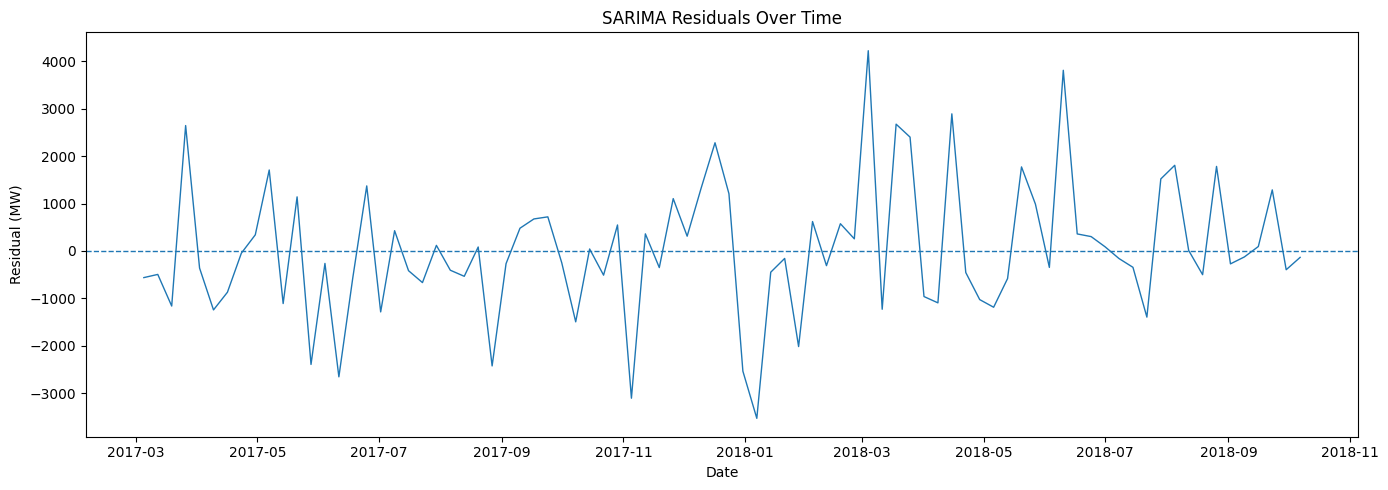

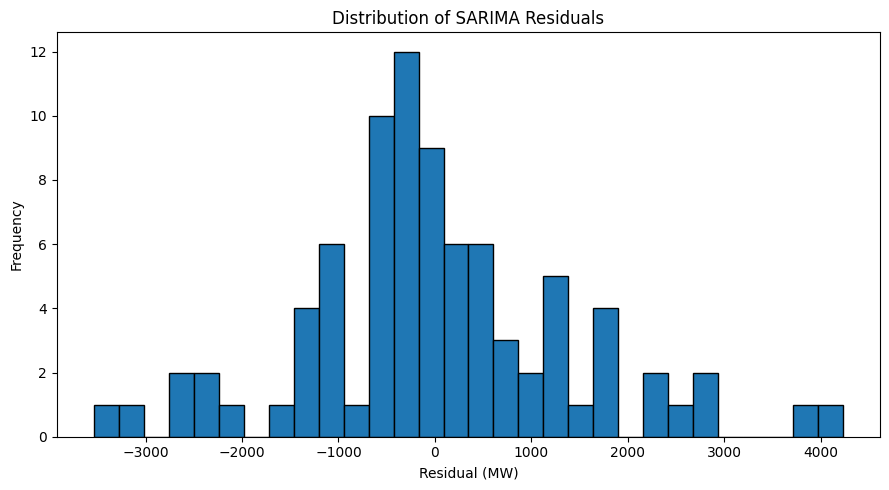

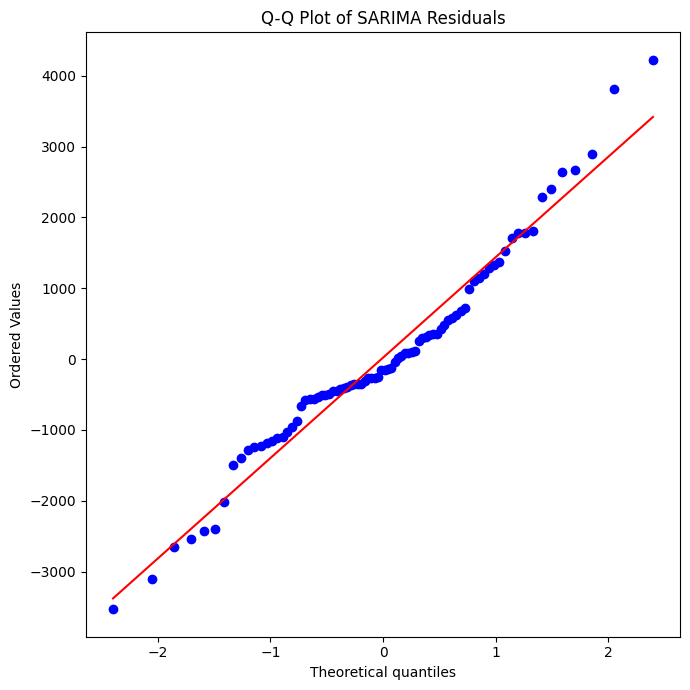

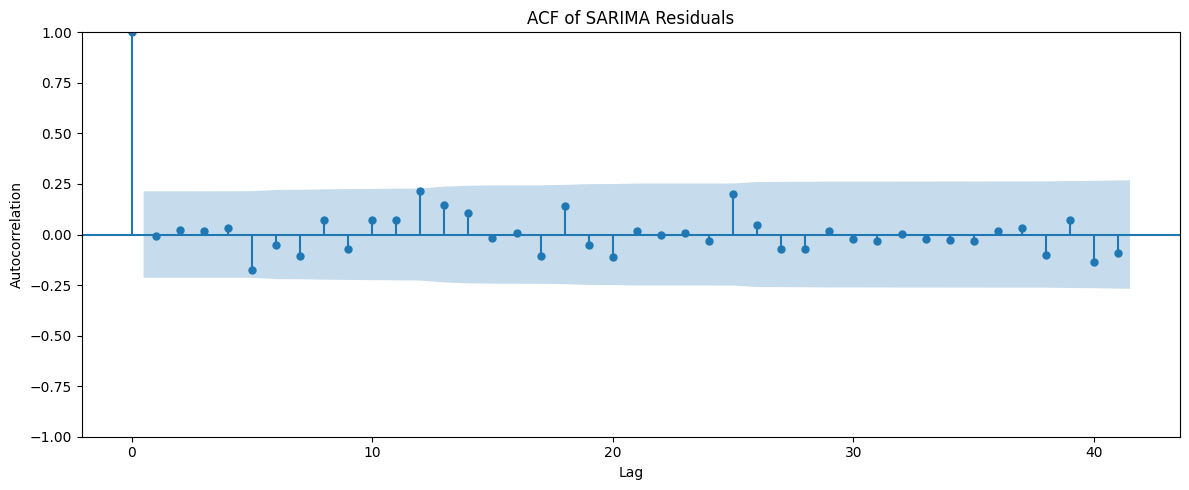


LJUNG-BOX TEST ON SARIMA RESIDUALS
    lb_stat  lb_pvalue
12  10.9967     0.5292
24  19.8043     0.7079
52  41.1232     0.8610

SARIMA FORECAST PERFORMANCE
MAE  : 3973.26 MW
RMSE : 4853.17 MW
MAPE : 7.53%

SARIMA VS SEASONAL NAIVE
Seasonal Naive RMSE : 3006.76 MW
SARIMA RMSE         : 4853.17 MW
RMSE improvement    : -61.41%

Seasonal Naive MAPE : 4.41%
SARIMA MAPE         : 7.53%
MAPE improvement    : -70.77%

SARIMA did not outperform the Seasonal Naive benchmark based on RMSE.


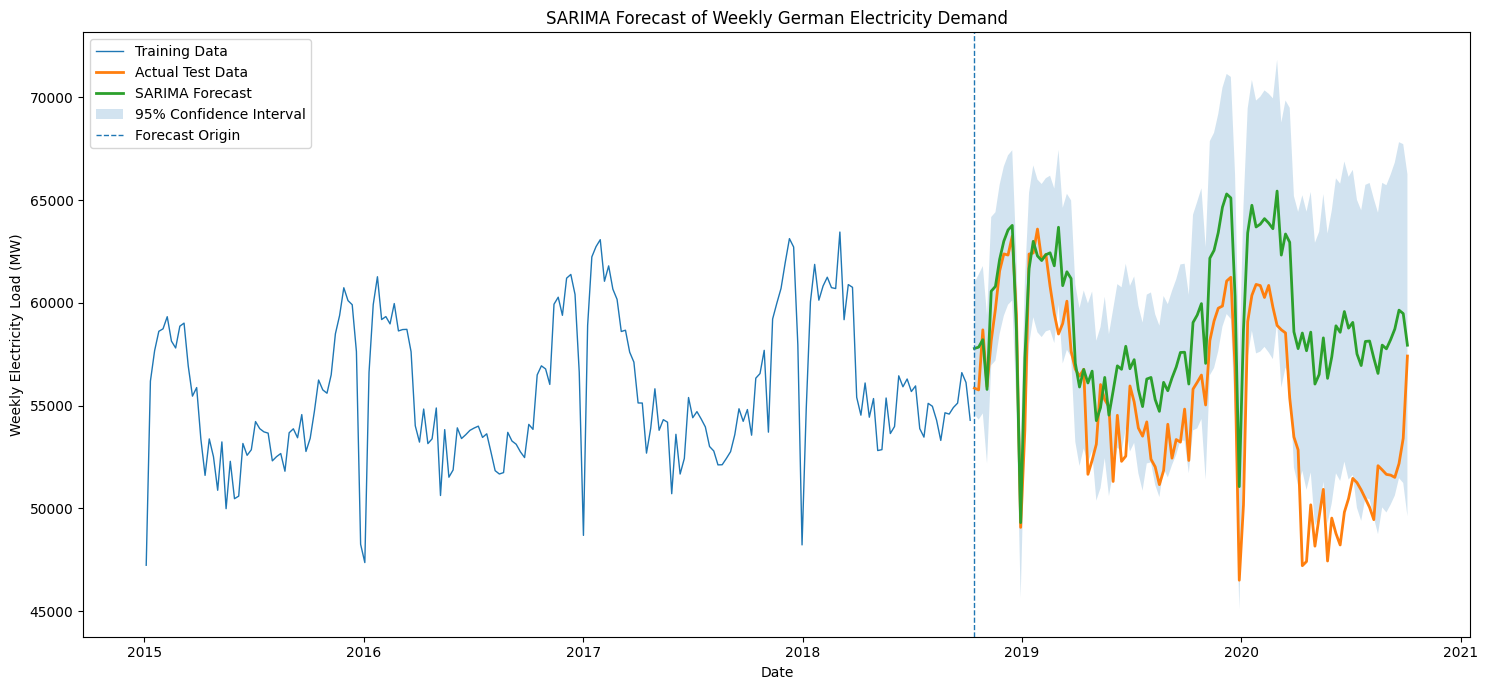

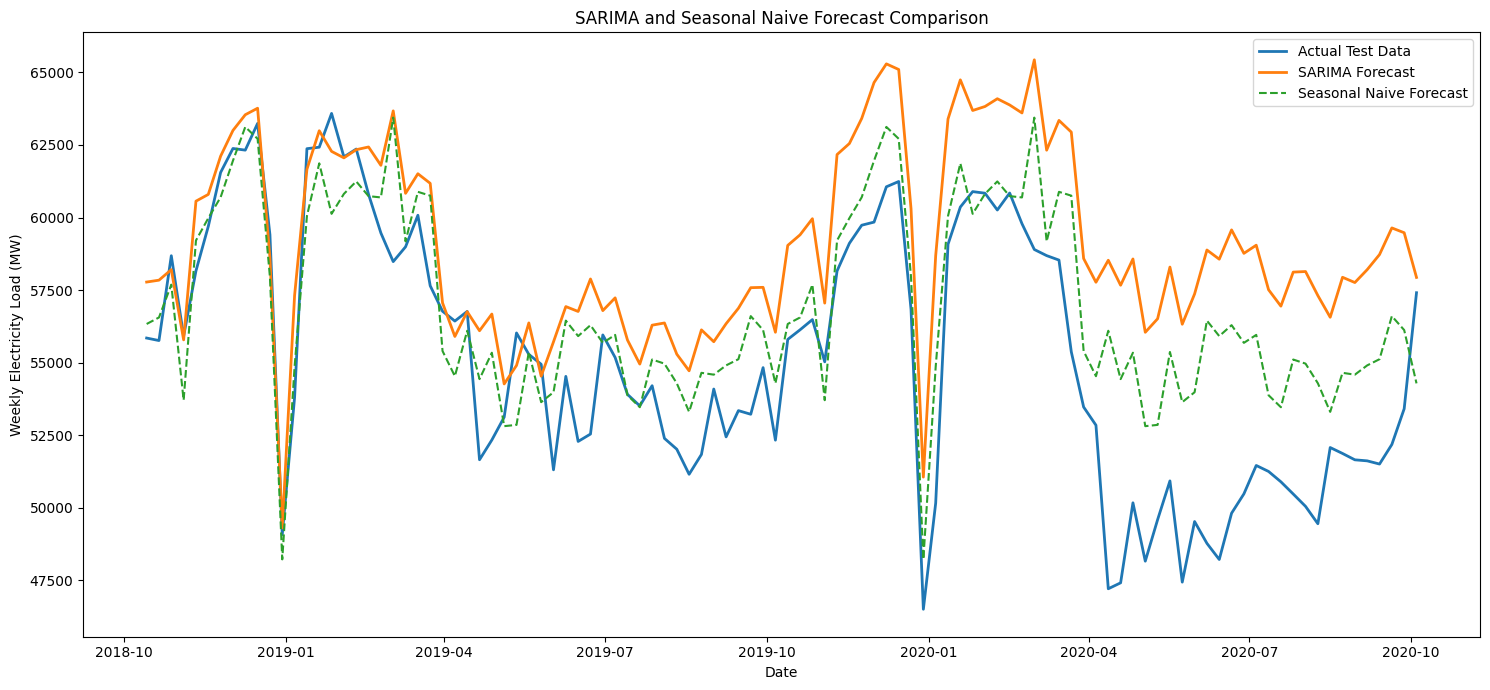


SARIMA ANALYSIS COMPLETED SUCCESSFULLY
Parameter-search results saved in the 'results' folder.
Forecast values and performance metrics saved in the 'results' folder.
Residual and forecast figures saved in the 'figures' folder.


In [10]:
# SARIMA MODEL

import os
import time
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

warnings.filterwarnings("ignore")

# Create output folders
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 1. PREPARE TRAINING AND TESTING SERIES

sarima_train = train["Load"].astype(float).dropna()
sarima_test = test["Load"].astype(float).dropna()

seasonal_period = 52

if len(sarima_train) < 2 * seasonal_period:
    raise ValueError(
        "The training dataset must contain at least two complete "
        "52-week seasonal cycles."
    )

if len(sarima_test) != 104:
    print(
        f"Warning: the test set contains {len(sarima_test)} weeks "
        "rather than exactly 104 weeks."
    )

print("=" * 70)
print("SARIMA ANALYSIS")
print("=" * 70)

print("Training observations :", len(sarima_train))
print("Testing observations  :", len(sarima_test))
print("Training period       :", sarima_train.index.min(),
      "to", sarima_train.index.max())
print("Testing period        :", sarima_test.index.min(),
      "to", sarima_test.index.max())
print("Seasonal period       :", seasonal_period, "weeks")


# 2. FORECAST-EVALUATION FUNCTION

def evaluate_forecast(actual, forecast):
    """
    Calculate MAE, RMSE and MAPE.

    Parameters
    ----------
    actual : pandas Series
        Actual observations.

    forecast : pandas Series
        Forecast observations aligned with actual.

    Returns
    -------
    dict
        Dictionary containing MAE, RMSE and MAPE.
    """

    actual = pd.Series(actual, dtype=float)
    forecast = pd.Series(
        np.asarray(forecast, dtype=float),
        index=actual.index
    )

    if len(actual) != len(forecast):
        raise ValueError(
            "Actual and forecast series must have equal lengths."
        )

    if actual.isna().any() or forecast.isna().any():
        raise ValueError(
            "Actual and forecast values must not contain missing values."
        )

    mae = mean_absolute_error(actual, forecast)

    rmse = np.sqrt(
        mean_squared_error(actual, forecast)
    )

    # Prevent division by zero in MAPE
    non_zero_mask = actual != 0

    mape = (
        np.mean(
            np.abs(
                (
                    actual[non_zero_mask]
                    - forecast[non_zero_mask]
                )
                / actual[non_zero_mask]
            )
        )
        * 100
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }


# 3. FUNCTION FOR FITTING ONE SARIMA CANDIDATE

def fit_sarima_candidate(
    series,
    order,
    seasonal_order,
    maxiter=60
):
    """
    Fit one SARIMA candidate and return model-selection results.

    Models that fail or produce non-finite information criteria
    return None so the search can continue.
    """

    try:
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=False
        )

        fitted = model.fit(
            method="lbfgs",
            maxiter=maxiter,
            disp=False
        )

        converged = fitted.mle_retvals.get(
            "converged",
            True
        )

        if not np.isfinite(fitted.aic):
            return None

        return {
            "Order": order,
            "Seasonal_Order": seasonal_order,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "Log_Likelihood": fitted.llf,
            "Converged": converged
        }

    except Exception:
        return None


# EXHAUSTIVE SEARCH OF REQUIRED p, d, q VALUES

# required ranges:
# p = 0 to 6
# d = 0 to 2
# q = 0 to 6

p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)

non_seasonal_orders = list(
    itertools.product(
        p_values,
        d_values,
        q_values
    )
)

print("\n" + "=" * 70)
print("EXHAUSTIVE NON-SEASONAL SEARCH")
print("=" * 70)

print(
    "Candidate p,d,q combinations:",
    len(non_seasonal_orders)
)

stage1_results = []
stage1_start_time = time.time()

for candidate_number, order in enumerate(
    non_seasonal_orders,
    start=1
):

    result = fit_sarima_candidate(
        series=sarima_train,
        order=order,
        seasonal_order=(0, 0, 0, 0),
        maxiter=50
    )

    if result is not None:
        stage1_results.append(result)

    if (
        candidate_number % 20 == 0
        or candidate_number == len(non_seasonal_orders)
    ):
        print(
            f"Checked {candidate_number} of "
            f"{len(non_seasonal_orders)} models"
        )

stage1_runtime = time.time() - stage1_start_time

stage1_df = pd.DataFrame(stage1_results)

if stage1_df.empty:
    raise RuntimeError(
        "No Stage 1 models fitted successfully."
    )

stage1_df = stage1_df[
    np.isfinite(stage1_df["AIC"])
].copy()

# Prefer models that converged
stage1_converged = stage1_df[
    stage1_df["Converged"] == True
].copy()

if not stage1_converged.empty:
    stage1_ranking = stage1_converged
else:
    print(
        "Warning: no Stage 1 model reported convergence. "
        "All successful fits will be ranked."
    )
    stage1_ranking = stage1_df

stage1_ranking = (
    stage1_ranking
    .sort_values("AIC")
    .reset_index(drop=True)
)

print(
    f"\nStage 1 runtime: "
    f"{stage1_runtime / 60:.2f} minutes"
)

print("\nTop 10 non-seasonal specifications:")

print(
    stage1_ranking[
        [
            "Order",
            "AIC",
            "BIC",
            "Converged"
        ]
    ]
    .head(10)
    .round(2)
    .to_string(index=False)
)

stage1_ranking.to_csv(
    "results/sarima_stage1_pdq_search.csv",
    index=False
)


# SEASONAL REFINEMENT OF TOP NON-SEASONAL MODELS

# Retain the strongest non-seasonal candidates
number_of_top_orders = 8

top_non_seasonal_orders = (
    stage1_ranking
    .head(number_of_top_orders)["Order"]
    .tolist()
)

# Practical seasonal search range
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

seasonal_orders = [
    (P, D, Q, seasonal_period)
    for P, D, Q in itertools.product(
        P_values,
        D_values,
        Q_values
    )
]

total_stage2_candidates = (
    len(top_non_seasonal_orders)
    * len(seasonal_orders)
)

print("\n" + "=" * 70)
print("SEASONAL PARAMETER REFINEMENT")
print("=" * 70)

print("Top p,d,q candidates:")
for order in top_non_seasonal_orders:
    print(order)

print(
    "\nSeasonal combinations:",
    len(seasonal_orders)
)

print(
    "Total Stage 2 candidates:",
    total_stage2_candidates
)

stage2_results = []
stage2_start_time = time.time()
stage2_counter = 0

for order in top_non_seasonal_orders:

    for seasonal_order in seasonal_orders:

        stage2_counter += 1

        result = fit_sarima_candidate(
            series=sarima_train,
            order=order,
            seasonal_order=seasonal_order,
            maxiter=100
        )

        if result is not None:
            stage2_results.append(result)

        if (
            stage2_counter % 10 == 0
            or stage2_counter == total_stage2_candidates
        ):
            print(
                f"Checked {stage2_counter} of "
                f"{total_stage2_candidates} seasonal models"
            )

stage2_runtime = time.time() - stage2_start_time

stage2_df = pd.DataFrame(stage2_results)

if stage2_df.empty:
    raise RuntimeError(
        "No seasonal SARIMA models fitted successfully."
    )

stage2_df = stage2_df[
    np.isfinite(stage2_df["AIC"])
].copy()

stage2_converged = stage2_df[
    stage2_df["Converged"] == True
].copy()

if not stage2_converged.empty:
    sarima_ranking = stage2_converged
else:
    print(
        "Warning: no Stage 2 model reported convergence. "
        "All successful fits will be ranked."
    )
    sarima_ranking = stage2_df

sarima_ranking = (
    sarima_ranking
    .sort_values("AIC")
    .reset_index(drop=True)
)

print(
    f"\nStage 2 runtime: "
    f"{stage2_runtime / 60:.2f} minutes"
)

print("\nTop 10 seasonal SARIMA specifications:")

print(
    sarima_ranking[
        [
            "Order",
            "Seasonal_Order",
            "AIC",
            "BIC",
            "Converged"
        ]
    ]
    .head(10)
    .round(2)
    .to_string(index=False)
)

sarima_ranking.to_csv(
    "results/sarima_stage2_seasonal_search.csv",
    index=False
)


# 6. SELECT THE LOWEST-AIC CONVERGED MODEL

best_order = tuple(
    sarima_ranking.loc[0, "Order"]
)

best_seasonal_order = tuple(
    sarima_ranking.loc[0, "Seasonal_Order"]
)

selected_aic = sarima_ranking.loc[0, "AIC"]
selected_bic = sarima_ranking.loc[0, "BIC"]

print("\n" + "=" * 70)
print("SELECTED SARIMA SPECIFICATION")
print("=" * 70)

print("Order               :", best_order)
print("Seasonal order      :", best_seasonal_order)
print(f"Selection-stage AIC : {selected_aic:.2f}")
print(f"Selection-stage BIC : {selected_bic:.2f}")


# 7. REFIT THE SELECTED MODEL CAREFULLY

final_sarima_model = SARIMAX(
    sarima_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=False
)

final_sarima_result = final_sarima_model.fit(
    method="lbfgs",
    maxiter=250,
    disp=False
)

final_converged = final_sarima_result.mle_retvals.get(
    "converged",
    True
)

print("\nFinal model converged:", final_converged)
print(f"Final model AIC     : {final_sarima_result.aic:.2f}")
print(f"Final model BIC     : {final_sarima_result.bic:.2f}")

print("\nFinal SARIMA model summary:")
print(final_sarima_result.summary())


# 8. RESIDUAL DIAGNOSTICS

sarima_residuals = (
    final_sarima_result.resid
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Remove early initialisation residuals where appropriate
burn_in = max(
    int(final_sarima_result.loglikelihood_burn),
    0
)

if burn_in < len(sarima_residuals):
    diagnostic_residuals = sarima_residuals.iloc[
        burn_in:
    ]
else:
    diagnostic_residuals = sarima_residuals.copy()

print("\nResidual mean:",
      round(diagnostic_residuals.mean(), 4))

print("Residual standard deviation:",
      round(diagnostic_residuals.std(), 4))


# 8.1 Residual time-series plot

plt.figure(figsize=(14, 5))

plt.plot(
    diagnostic_residuals.index,
    diagnostic_residuals,
    linewidth=1
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("SARIMA Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (MW)")
plt.tight_layout()

plt.savefig(
    "figures/sarima_residual_time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 8.2 Residual distribution

plt.figure(figsize=(9, 5))

plt.hist(
    diagnostic_residuals,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of SARIMA Residuals")
plt.xlabel("Residual (MW)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "figures/sarima_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 8.3 Q-Q plot

plt.figure(figsize=(7, 7))

stats.probplot(
    diagnostic_residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of SARIMA Residuals")
plt.tight_layout()

plt.savefig(
    "figures/sarima_residual_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 8.4 Residual ACF

maximum_residual_lag = min(
    60,
    (len(diagnostic_residuals) // 2) - 1
)

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    diagnostic_residuals,
    lags=maximum_residual_lag,
    ax=ax
)

ax.set_title("ACF of SARIMA Residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()

plt.savefig(
    "figures/sarima_residual_acf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 8.5 Ljung-Box test

available_lags = [
    lag for lag in [12, 24, 52]
    if lag < len(diagnostic_residuals)
]

ljung_box_results = acorr_ljungbox(
    diagnostic_residuals,
    lags=available_lags,
    return_df=True
)

print("\n" + "=" * 70)
print("LJUNG-BOX TEST ON SARIMA RESIDUALS")
print("=" * 70)

print(
    ljung_box_results
    .round(4)
    .to_string()
)

ljung_box_results.to_csv(
    "results/sarima_ljung_box_results.csv"
)


# 9. FORECAST THE FINAL TWO YEARS

sarima_forecast_object = (
    final_sarima_result
    .get_forecast(
        steps=len(sarima_test)
    )
)

sarima_forecast = pd.Series(
    sarima_forecast_object.predicted_mean.to_numpy(),
    index=sarima_test.index,
    name="SARIMA Forecast"
)

confidence_intervals = (
    sarima_forecast_object
    .conf_int(alpha=0.05)
)

sarima_lower_ci = pd.Series(
    confidence_intervals.iloc[:, 0].to_numpy(),
    index=sarima_test.index,
    name="Lower 95% CI"
)

sarima_upper_ci = pd.Series(
    confidence_intervals.iloc[:, 1].to_numpy(),
    index=sarima_test.index,
    name="Upper 95% CI"
)


# 10. EVALUATE SARIMA FORECAST

sarima_metrics = evaluate_forecast(
    actual=sarima_test,
    forecast=sarima_forecast
)

mae_sarima = sarima_metrics["MAE"]
rmse_sarima = sarima_metrics["RMSE"]
mape_sarima = sarima_metrics["MAPE (%)"]

print("\n" + "=" * 70)
print("SARIMA FORECAST PERFORMANCE")
print("=" * 70)

print(f"MAE  : {mae_sarima:.2f} MW")
print(f"RMSE : {rmse_sarima:.2f} MW")
print(f"MAPE : {mape_sarima:.2f}%")


# 11. RECREATE SEASONAL-NAIVE BENCHMARK

last_training_season = (
    sarima_train
    .iloc[-seasonal_period:]
    .to_numpy()
)

seasonal_naive_values = np.tile(
    last_training_season,
    int(
        np.ceil(
            len(sarima_test) / seasonal_period
        )
    )
)[:len(sarima_test)]

seasonal_naive_sarima_comparison = pd.Series(
    seasonal_naive_values,
    index=sarima_test.index,
    name="Seasonal Naive Forecast"
)

seasonal_naive_metrics = evaluate_forecast(
    actual=sarima_test,
    forecast=seasonal_naive_sarima_comparison
)

rmse_seasonal_benchmark = seasonal_naive_metrics["RMSE"]
mape_seasonal_benchmark = seasonal_naive_metrics["MAPE (%)"]


# 12. CALCULATE IMPROVEMENT OVER SEASONAL NAIVE

rmse_improvement_percentage = (
    (
        rmse_seasonal_benchmark
        - rmse_sarima
    )
    / rmse_seasonal_benchmark
) * 100

mape_improvement_percentage = (
    (
        mape_seasonal_benchmark
        - mape_sarima
    )
    / mape_seasonal_benchmark
) * 100

print("\n" + "=" * 70)
print("SARIMA VS SEASONAL NAIVE")
print("=" * 70)

print(
    f"Seasonal Naive RMSE : "
    f"{rmse_seasonal_benchmark:.2f} MW"
)

print(
    f"SARIMA RMSE         : "
    f"{rmse_sarima:.2f} MW"
)

print(
    f"RMSE improvement    : "
    f"{rmse_improvement_percentage:.2f}%"
)

print(
    f"\nSeasonal Naive MAPE : "
    f"{mape_seasonal_benchmark:.2f}%"
)

print(
    f"SARIMA MAPE         : "
    f"{mape_sarima:.2f}%"
)

print(
    f"MAPE improvement    : "
    f"{mape_improvement_percentage:.2f}%"
)

if rmse_sarima < rmse_seasonal_benchmark:
    print(
        "\nSARIMA outperformed the Seasonal Naive "
        "benchmark based on RMSE."
    )
else:
    print(
        "\nSARIMA did not outperform the Seasonal Naive "
        "benchmark based on RMSE."
    )


# 13. FORECAST PLOT WITH CONFIDENCE INTERVALS

plt.figure(figsize=(15, 7))

plt.plot(
    sarima_train.index,
    sarima_train,
    label="Training Data",
    linewidth=1
)

plt.plot(
    sarima_test.index,
    sarima_test,
    label="Actual Test Data",
    linewidth=2
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    sarima_test.index,
    sarima_lower_ci,
    sarima_upper_ci,
    alpha=0.20,
    label="95% Confidence Interval"
)

plt.axvline(
    x=sarima_test.index[0],
    linestyle="--",
    linewidth=1,
    label="Forecast Origin"
)

plt.title(
    "SARIMA Forecast of Weekly German Electricity Demand"
)

plt.xlabel("Date")
plt.ylabel("Weekly Electricity Load (MW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/sarima_forecast_with_confidence_interval.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 14. TEST-PERIOD COMPARISON PLOT

plt.figure(figsize=(15, 7))

plt.plot(
    sarima_test.index,
    sarima_test,
    label="Actual Test Data",
    linewidth=2
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA Forecast",
    linewidth=2
)

plt.plot(
    seasonal_naive_sarima_comparison.index,
    seasonal_naive_sarima_comparison,
    label="Seasonal Naive Forecast",
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "SARIMA and Seasonal Naive Forecast Comparison"
)

plt.xlabel("Date")
plt.ylabel("Weekly Electricity Load (MW)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/sarima_vs_seasonal_naive.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 15. SAVE FORECAST VALUES

sarima_forecast_output = pd.DataFrame({
    "Actual": sarima_test,
    "SARIMA_Forecast": sarima_forecast,
    "Lower_95_CI": sarima_lower_ci,
    "Upper_95_CI": sarima_upper_ci,
    "Seasonal_Naive_Forecast":
        seasonal_naive_sarima_comparison
})

sarima_forecast_output.to_csv(
    "results/sarima_forecast_values.csv"
)


# 16. SAVE PERFORMANCE SUMMARY

sarima_performance = pd.DataFrame({
    "Model": ["SARIMA"],
    "Order": [str(best_order)],
    "Seasonal_Order": [
        str(best_seasonal_order)
    ],
    "Converged": [final_converged],
    "AIC": [final_sarima_result.aic],
    "BIC": [final_sarima_result.bic],
    "MAE": [mae_sarima],
    "RMSE": [rmse_sarima],
    "MAPE (%)": [mape_sarima],
    "Seasonal_Naive_RMSE": [
        rmse_seasonal_benchmark
    ],
    "RMSE_Improvement_over_Seasonal_Naive (%)": [
        rmse_improvement_percentage
    ]
})

sarima_performance.to_csv(
    "results/sarima_model_performance.csv",
    index=False
)

print("\n" + "=" * 70)
print("SARIMA ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "Parameter-search results saved in the "
    "'results' folder."
)

print(
    "Forecast values and performance metrics saved in "
    "the 'results' folder."
)

print(
    "Residual and forecast figures saved in the "
    "'figures' folder."
)